# Operaciones de Aprendizaje Automático TC5061.10 | Actividad | Dataset - Notebook | Individual

**Alumno:** Roberto Robles   
**Matrícula:** A00493836   
**Curso:** TC5061.10 Operaciones de Aprendizaje Automático    
**Fecha:** 30 de septiembre de 2026. 

**Dataset:** `cancer_trials_2020_2024.csv` => 10,000 ensayos clínicos de cáncer registrados en ClinicalTrials.gov.

**Problema a resolver:** Regresión. Predecir la **duración de un ensayo clínico (en días)** a partir de sus características.

**Contenido**

0. Configuración del ambiente
1. Carga y descripción del dataset
2. Análisis exploratorio (EDA)
3. Limpieza de datos
4. Modelo base (baseline)
5. Evaluación del modelo
6. Registro del experimento en MLflow
7. Reflexión final


In [11]:
# === 0. Configuración del entorno ===

# Librerías para manejo de datos
import sys
import subprocess
from importlib.metadata import version
import numpy as np
import pandas as pd

# Librerías para visualización
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de modelado y tracking de experimentos
import sklearn
import mlflow

# Semilla fija: garantiza que la división train/test y el modelo den
# siempre el mismo resultado (reproducibilidad)
SEED = 42
np.random.seed(SEED)

# Estilo de las gráficas
sns.set_theme(style="whitegrid")

# --- Evidencia de versiones, leída desde requirements.txt ---
# Se toma el nombre de cada paquete (ignorando comentarios y líneas vacías)
with open("requirements.txt") as f:
    paquetes = [linea.split("#")[0].strip() for linea in f]
    paquetes = [p for p in paquetes if p]

print(f"{'python':<13}: {sys.version.split()[0]}")
for paquete in paquetes:
    print(f"{paquete:<13}: {version(paquete)}")

# --- Congelar el entorno completo en requirements-lock.txt ---
# sys.executable es el Python del kernel (.venv), así se congela ese entorno
lock = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True, text=True, check=True,
).stdout
with open("requirements-lock.txt", "w") as f:
    f.write(lock)
print(f"\nrequirements-lock.txt actualizado ({len(lock.splitlines())} paquetes)")

python       : 3.13.9
pandas       : 3.0.6
numpy        : 2.5.3
matplotlib   : 3.11.2
seaborn      : 0.13.2
scikit-learn : 1.9.1
mlflow       : 3.16.1
ipykernel    : 7.4.0

requirements-lock.txt actualizado (113 paquetes)


## 1. Carga y descripción del dataset

Se carga el archivo CSV original en un DataFrame llamado `df_cancer`. Este DataFrame **no se modifica** en ningún momento. Todas las transformaciones posteriores se harán sobre una copia, para mantener integridad del dataset original y permitir que el proceso sea auditable.

In [12]:
# === 1.1 Carga del dataset ===

# Ruta: el CSV está en la misma carpeta que el notebook
DATA_PATH = "cancer_trials_2020_2024.csv"

# Leer el CSV en un DataFrame de pandas
df_cancer = pd.read_csv(DATA_PATH)

# Dimensiones: (número de registros, número de variables)
print(f"Registros : {df_cancer.shape[0]:,}")
print(f"Variables : {df_cancer.shape[1]}")

# Vista previa de las primeras 5 filas
df_cancer.head()

Registros : 10,000
Variables : 14


,nct_id,study_title,study_status,study_type,phase,conditions,interventions,intervention_types,lead_sponsor,sponsor_type,enrollment,sex,start_date,completion_date
0,NCT02953652,Efficacy and Safety of Oral HBI-8000 in Patien...,COMPLETED,INTERVENTIONAL,PHASE2,Peripheral T-Cell Lymphoma (PTCL),HBI-8000,DRUG,"HUYABIO International, LLC.",INDUSTRY,55,ALL,2016-11,2022-02-17
1,NCT03693547,Clinical Study of Utidelone Injection in Patie...,COMPLETED,INTERVENTIONAL,PHASE2,Advanced Non-small Cell Lung Cancer,utidelone injection,DRUG,"Beijing Biostar Pharmaceuticals Co., Ltd.",INDUSTRY,26,ALL,2019-04-22,2021-08-10
2,NCT04239976,Scrambler Therapy for the Reduction of Chemoth...,COMPLETED,INTERVENTIONAL,NaN,Chemotherapy-Induced Peripheral Neuropathy; Ma...,FitBit; Gait Assessment Test; MC5-A Scrambler ...,PROCEDURE; OTHER; DEVICE,M.D. Anderson Cancer Center,OTHER,16,ALL,2019-04-04,2022-03-18
3,NCT04281576,"Effect of Tumor Treating Fields (TTFields, 150...",COMPLETED,INTERVENTIONAL,NaN,Gastric Cancer; GastroEsophageal Cancer,NovoTTF-100L(P); Oxaliplatin; Capecitabine; Tr...,DRUG; DEVICE,NovoCure Ltd.,INDUSTRY,28,ALL,2019-12-19,2024-06-07
4,NCT02549989,Study of LY3023414 for the Treatment of Recurr...,COMPLETED,INTERVENTIONAL,PHASE2,Endometrial Cancer; Recurrent Endometrial Cancer,LY3023414,DRUG,Memorial Sloan Kettering Cancer Center,OTHER,28,FEMALE,2015-09,2022-03-23


In [13]:
# === 1.2 Estructura: tipos de dato y valores no nulos por columna ===
df_cancer.info()

# Número de valores distintos por columna: ayuda a distinguir
# identificadores, variables numéricas, variables categóricas y texto libre
print("\nValores únicos por columna:")
print(df_cancer.nunique().sort_values())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   nct_id              10000 non-null  str  
 1   study_title         10000 non-null  str  
 2   study_status        10000 non-null  str  
 3   study_type          10000 non-null  str  
 4   phase               7285 non-null   str  
 5   conditions          10000 non-null  str  
 6   interventions       9095 non-null   str  
 7   intervention_types  9097 non-null   str  
 8   lead_sponsor        10000 non-null  str  
 9   sponsor_type        10000 non-null  str  
 10  enrollment          10000 non-null  int64
 11  sex                 10000 non-null  str  
 12  start_date          10000 non-null  str  
 13  completion_date     10000 non-null  str  
dtypes: int64(1), str(13)
memory usage: 3.9 MB

Valores únicos por columna:
study_status              1
study_type                2
sex                

### 1.3 Diccionario de datos

El conjunto de datos tiene **10,000 registros** (un ensayo clínico por fila) y **14 variables**: 13 de texto (`str`) y 1 numérica (`int64`).

| # | Variable | Tipo en pandas | Tipo conceptual | Significado | Valores únicos | Uso previsto |
|---|---|---|---|---|---|---|
| 0 | `nct_id` | str | Identificador | ID único del ensayo en ClinicalTrials.gov (NCT + 8 dígitos) | 10,000 | Excluir (no predictiva) |
| 1 | `study_title` | str | Texto libre | Título oficial del estudio | 9,997 | Excluir (texto libre) |
| 2 | `study_status` | str | Categórica | Estado del ensayo | 1 (`COMPLETED`) | Excluir (constante) |
| 3 | `study_type` | str | Categórica binaria | Intervencional (se asigna un tratamiento) u observacional (solo se observa) | 2 | Predictora |
| 4 | `phase` | str | Categórica ordinal | Fase del ensayo clínico (Early Phase 1 a Phase 4) | 8 | Predictora |
| 5 | `conditions` | str | Texto multivalor | Tipo(s) de cáncer o condición estudiada, separados por `;` | 5,773 | Excluir del modelo base (alta cardinalidad) |
| 6 | `interventions` | str | Texto multivalor | Nombre del tratamiento o intervención aplicada | 8,403 | Excluir del modelo base (alta cardinalidad) |
| 7 | `intervention_types` | str | Categórica multivalor | Tipo(s) de intervención: DRUG, PROCEDURE, BEHAVIORAL, etc. | 137 | Predictora (simplificada) |
| 8 | `lead_sponsor` | str | Categórica | Institución o empresa que patrocina el ensayo | 2,742 | Excluir del modelo base (alta cardinalidad) |
| 9 | `sponsor_type` | str | Categórica | Tipo de patrocinador: industria, NIH, gobierno, otro | 8 | Predictora |
| 10 | `enrollment` | int64 | Numérica discreta | Número de participantes inscritos | 1,293 | Predictora |
| 11 | `sex` | str | Categórica | Sexo de los participantes elegibles: ALL, FEMALE, MALE | 3 | Predictora |
| 12 | `start_date` | str | Fecha | Fecha de inicio del ensayo | 3,394 | Para calcular la variable objetivo |
| 13 | `completion_date` | str | Fecha | Fecha de término del ensayo | 1,668 | Para calcular la variable objetivo |

**Variable objetivo (a construir en el Paso 3):** `duration_days` = `completion_date` − `start_date`, es decir, la duración del ensayo en días.

### 1.4 Hallazgos iniciales

A partir de la carga y la revisión de la estructura (`head()`, `info()` y `nunique()`), se identifica lo siguiente:

**Sobre el contenido de los datos**
- Cada registro representa **un ensayo clínico de cáncer** registrado en ClinicalTrials.gov. `nct_id` es único en los 10,000 registros, por lo que lo consideramos como llave primaria.
- Todos los ensayos tienen estado `COMPLETED`, por lo que `study_status` **no aporta información** y no es posible predecir si un ensayo se completa o se cancela. Por eso el problema se plantea como **regresión de la duración** del ensayo.

**Sobre la calidad de los datos**
- **Valores a cambiar (es fecha pero se guardó como texto):** `start_date` y `completion_date` se leyeron como texto (`str`) y deben convertirse a fecha para calcular la duración.
- **Valores faltantes:** `phase` (2,715; 27%), `interventions` (905; 9%) e `intervention_types` (903; 9%).
- **Variable constante:** `study_status` (1 valor único).
- **Alta cardinalidad:** `conditions` (5,773), `interventions` (8,403) y `lead_sponsor` (2,742) tienen demasiados valores distintos para usarse directamente en un modelo base.
- **Texto libre:** `study_title` no se usará en el baseline; requeriría técnicas de procesamiento de lenguaje natural (NLP) que están fuera del alcance de esta actividad.
- **Única variable numérica:** `enrollment`. Las demás predictoras son categóricas y deberán codificarse (por ejemplo, con one-hot encoding) antes de entrenar.

## 2. Análisis exploratorio de datos (EDA)

El objetivo de esta sección es entender la distribución de cada variable y su relación con la duración del ensayo, antes de tomar decisiones de limpieza.

### 2.1 Estadísticas descriptivas

Se calculan las medidas de tendencia central, dispersión y forma (sesgo y curtosis) de la variable numérica, y el número de categorías y la categoría más frecuente de las variables categóricas.

In [14]:
# === 2.1 Estadísticas descriptivas ===

# --- Variable numérica ---
# describe(): conteo, media, desviación estándar, mínimo, cuartiles y máximo
resumen_num = df_cancer[["enrollment"]].describe().T

# Sesgo: mide la asimetría de la distribución
#   ≈ 0 → simétrica | > 0 → cola larga a la derecha | < 0 → cola larga a la izquierda
resumen_num["sesgo"] = df_cancer["enrollment"].skew()

# Curtosis (exceso, Fisher): mide qué tan "pesadas" son las colas
#   ≈ 0 → similar a una normal | > 0 → colas pesadas (muchos valores extremos)
resumen_num["curtosis"] = df_cancer["enrollment"].kurt()

print("Variable numérica (enrollment):")
display(resumen_num)

# --- Variables categóricas ---
# describe(): conteo, número de categorías, categoría más frecuente (top) y su frecuencia
columnas_categoricas = ["study_type", "phase", "intervention_types", "sponsor_type", "sex"]
print("Variables categóricas:")
display(df_cancer[columnas_categoricas].describe().T)

Variable numérica (enrollment):


,count,mean,std,min,25%,50%,75%,max,sesgo,curtosis
enrollment,10000.0,9252.5283,408336.774587,1.0,30.0,66.0,193.0,36580288.0,76.530953,6563.520546


Variables categóricas:


,count,unique,top,freq
study_type,10000,2,INTERVENTIONAL,7394
phase,7285,8,Not Specified,2607
intervention_types,9097,137,DRUG,3290
sponsor_type,10000,8,OTHER,7075
sex,10000,3,ALL,7867


### 2.2 Distribución de variables numéricas

Para cada variable numérica se grafica un **histograma** (forma de la distribución) y un **diagrama de caja** (mediana, cuartiles y valores atípicos), marcando la **media** (rojo) y la **mediana** (verde). Los valores atípicos se cuantifican con la regla IQR: valores menores a Q1 − 1.5·IQR o mayores a Q3 + 1.5·IQR.

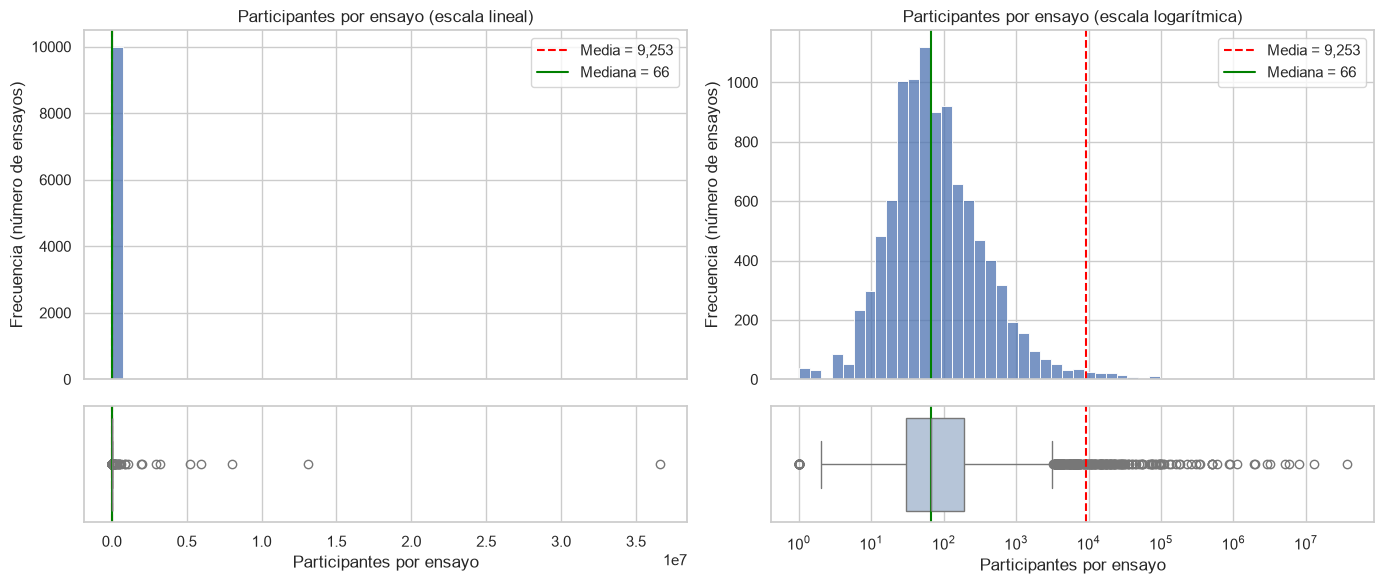

Q1 = 30 | Q3 = 193 | IQR = 163
Límites IQR: [-214.5 , 437.5]
Valores atípicos inferiores (< -214.5): 0 registros (0.0%)
Valores atípicos superiores (> 437.5): 1,309 registros (13.1%)


In [15]:
# === 2.2 Distribución de variables numéricas ===

def graficar_numerica(serie, nombre, log=False):
    """Grafica histograma + diagrama de caja de una variable numérica, con media y mediana.
    Si log=True, agrega una segunda columna en escala logarítmica
    (útil cuando los valores abarcan varios órdenes de magnitud)."""
    media, mediana = serie.mean(), serie.median()
    escalas = [False, True] if log else [False]

    # Cuadrícula: fila 1 = histogramas, fila 2 = diagramas de caja (más bajos)
    fig, ejes = plt.subplots(2, len(escalas), figsize=(7 * len(escalas), 6),
                             sharex="col", squeeze=False,
                             gridspec_kw={"height_ratios": [3, 1]})

    for j, escala_log in enumerate(escalas):
        ax_hist, ax_box = ejes[0, j], ejes[1, j]
        sns.histplot(serie, bins=50, log_scale=escala_log, ax=ax_hist)
        sns.boxplot(x=serie, log_scale=escala_log, ax=ax_box, color="lightsteelblue")

        # Líneas de media y mediana en ambas gráficas
        for ax in (ax_hist, ax_box):
            ax.axvline(media, color="red", linestyle="--", label=f"Media = {media:,.0f}")
            ax.axvline(mediana, color="green", label=f"Mediana = {mediana:,.0f}")
        ax_hist.legend()
        ax_hist.set_title(f"{nombre} (escala {'logarítmica' if escala_log else 'lineal'})")

        # Etiquetas de los ejes en español
        ax_hist.set_ylabel("Frecuencia (número de ensayos)")
        ax_box.set_xlabel(nombre)

    plt.tight_layout()
    plt.show()

    # Cuantificación de valores atípicos con la regla IQR (ambos extremos)
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_inf = (serie < lim_inf).sum()
    n_sup = (serie > lim_sup).sum()
    print(f"Q1 = {q1:,.0f} | Q3 = {q3:,.0f} | IQR = {iqr:,.0f}")
    print(f"Límites IQR: [{lim_inf:,.1f} , {lim_sup:,.1f}]")
    print(f"Valores atípicos inferiores (< {lim_inf:,.1f}): {n_inf:,} registros ({n_inf / len(serie):.1%})")
    print(f"Valores atípicos superiores (> {lim_sup:,.1f}): {n_sup:,} registros ({n_sup / len(serie):.1%})")


# Aplicar a enrollment, con escala lineal y logarítmica
graficar_numerica(df_cancer["enrollment"], "Participantes por ensayo", log=True)

In [16]:
# === Revisión de los valores extremos de enrollment ===
# Antes de decidir si son errores, se inspeccionan los ensayos con más participantes
columnas = ["nct_id", "enrollment", "study_type", "phase", "study_title"]
display(df_cancer.nlargest(10, "enrollment")[columnas])

# ¿Los valores altos se concentran en algún tipo de estudio?
print("Mediana de participantes por tipo de estudio:")
print(df_cancer.groupby("study_type")["enrollment"].median())

,nct_id,enrollment,study_type,phase,study_title
7239,NCT06268535,36580288,OBSERVATIONAL,Not Specified,Identification of Anticancer Drugs Associated ...
5131,NCT04365114,13094122,OBSERVATIONAL,Not Specified,Patient Outcomes from Second Film-readers and ...
9239,NCT06700941,8000000,OBSERVATIONAL,Not Specified,Impact of HPV Vaccination Against Cervical Les...
4324,NCT03847753,5940299,OBSERVATIONAL,Not Specified,Exploring the Comorbidity Between Mental Disor...
895,NCT06619535,5239194,OBSERVATIONAL,Not Specified,Sepsis As a Cause of Death Among Elderly Cance...
8331,NCT02875327,3217145,OBSERVATIONAL,Not Specified,Linkage of Medicaid Enrollment Information to ...
587,NCT04334824,2953748,OBSERVATIONAL,Not Specified,Hydrochlorothiazide and Risk of Skin Cancer
1141,NCT03904732,2000000,OBSERVATIONAL,Not Specified,Study to Develop a Prediction Model to Underst...
1617,NCT02936609,1939783,OBSERVATIONAL,Not Specified,Assessing Community Cancer Care After Insuranc...
9787,NCT06204133,1112846,OBSERVATIONAL,Not Specified,Model Study on Cervical Cancer Screening Strat...


Mediana de participantes por tipo de estudio:
study_type
INTERVENTIONAL     53.0
OBSERVATIONAL     171.0
Name: enrollment, dtype: float64


**Interpretación: número de participantes (`enrollment`)**

- **Distribución con fuerte sesgo a la derecha:** la media (9,253 participantes) es unas 140 veces mayor que la mediana (66). Unos pocos ensayos con millones de participantes elevan la media, por lo que la **mediana es la medida que mejor representa al ensayo típico**. Esto se confirma con un sesgo de ≈ 76.5 y una curtosis de ≈ 6,563 (colas extremadamente pesadas).
- **Escala:** en escala lineal la distribución no se aprecia; en escala logarítmica toma una forma aproximadamente acampanada. Esto sugiere que una **transformación logarítmica** puede ser útil para el modelo.
- **Valores atípicos:** con la regla IQR hay **0 valores atípicos inferiores** (el límite inferior es negativo, −214.5, imposible para un conteo de participantes) y **1,309 valores atípicos superiores (13.1%)**, por encima de 437.5 participantes.
- **¿Son errores de captura?** No. Al revisar los ensayos más grandes, corresponden a **estudios observacionales** que analizan bases de datos o registros poblacionales, no a reclutamiento individual de pacientes. La mediana de participantes por tipo de estudio lo confirma: observacionales = 171 contra intervencionales = 53.
- **Decisión preliminar:** los valores atípicos **no se eliminan**, porque representan estudios reales y el 13.1% de los datos. Su tratamiento, por ejemplo con una transformación logarítmica, se definirá en el Paso 3.

### 2.3 Variable objetivo: duración del ensayo

Para explorar la variable objetivo se convierten temporalmente las fechas de inicio (`start_date`) y de término (`completion_date`) a tipo fecha y se calcula la duración en días. `df_cancer` no se modifica: la conversión definitiva se realizará en el Paso 3.

In [17]:
# === 2.3 Variable objetivo: exploración de fechas y duración ===

# 1) ¿Todas las fechas tienen el mismo formato?
#    "AAAA-MM-DD" tiene 10 caracteres; "AAAA-MM" (sin día) tiene 7
print("Fechas sin día (formato AAAA-MM):")
for col in ["start_date", "completion_date"]:
    n_parcial = (df_cancer[col].str.len() == 7).sum()
    print(f"  {col:<16}: {n_parcial:,} ({n_parcial / len(df_cancer):.1%})")

# Por ensayo: ¿cuántos tienen al menos una fecha incompleta (|) y cuántos ambas (&)?
sin_dia_inicio = df_cancer["start_date"].str.len() == 7
sin_dia_fin = df_cancer["completion_date"].str.len() == 7
n_alguna = (sin_dia_inicio | sin_dia_fin).sum()
n_ambas = (sin_dia_inicio & sin_dia_fin).sum()
print(f"  Ensayos con al menos una fecha incompleta: {n_alguna:,} ({n_alguna / len(df_cancer):.1%})")
print(f"  Ensayos con ambas fechas incompletas     : {n_ambas:,} ({n_ambas / len(df_cancer):.1%})")

# 2) Conversión temporal a fecha (format="mixed" acepta ambos formatos;
#    a las fechas sin día pandas les asigna el día 1 del mes)
inicio = pd.to_datetime(df_cancer["start_date"], format="mixed")
fin = pd.to_datetime(df_cancer["completion_date"], format="mixed")

# 3) Rango de fechas: ¿qué periodo cubre realmente el conjunto de datos?
print(f"\nInicio  : {inicio.min().date()}  a  {inicio.max().date()}")
print(f"Término : {fin.min().date()}  a  {fin.max().date()}")

# 4) Duración en días = fecha de término − fecha de inicio
duracion_dias = (fin - inicio).dt.days

# 5) Validaciones de coherencia: una duración negativa sería un error
print(f"\nDuraciones negativas : {(duracion_dias < 0).sum()}")
print(f"Duraciones de 0 días : {(duracion_dias == 0).sum()}")

# 6) Estadísticas descriptivas, sesgo y curtosis
resumen_obj = duracion_dias.describe().to_frame("duracion_dias").T
resumen_obj["sesgo"] = duracion_dias.skew()
resumen_obj["curtosis"] = duracion_dias.kurt()
display(resumen_obj)

Fechas sin día (formato AAAA-MM):
  start_date      : 1,076 (10.8%)
  completion_date : 534 (5.3%)
  Ensayos con al menos una fecha incompleta: 1,139 (11.4%)
  Ensayos con ambas fechas incompletas     : 471 (4.7%)

Inicio  : 1979-01-01  a  2024-11-15
Término : 2020-01-01  a  2024-12-31

Duraciones negativas : 0
Duraciones de 0 días : 9


,count,mean,std,min,25%,50%,75%,max,sesgo,curtosis
duracion_dias,10000.0,1657.8163,1450.275894,0.0,664.0,1292.5,2191.0,15705.0,2.112297,7.277989


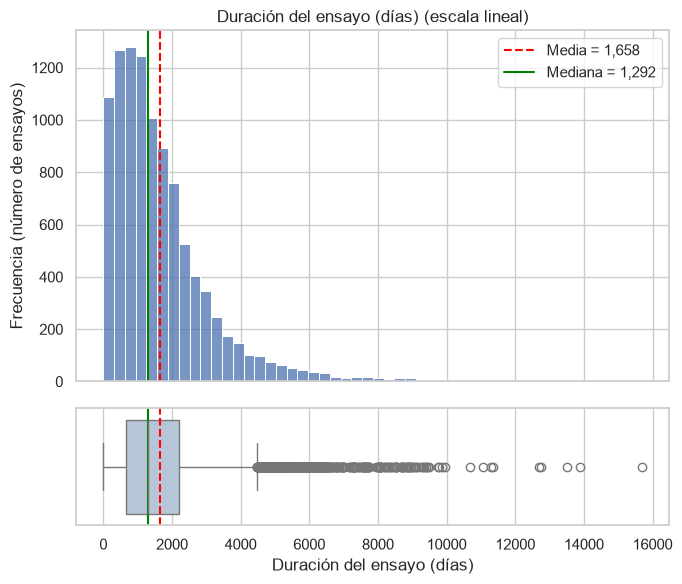

Q1 = 664 | Q3 = 2,191 | IQR = 1,527
Límites IQR: [-1,626.5 , 4,481.5]
Valores atípicos inferiores (< -1,626.5): 0 registros (0.0%)
Valores atípicos superiores (> 4,481.5): 492 registros (4.9%)


,nct_id,study_type,phase,enrollment,start_date,completion_date,study_title
2046,NCT06169930,OBSERVATIONAL,Not Specified,2957,2023-12-01,2023-12-01,Development and Validation of a Survival Predi...
2357,NCT05361655,OBSERVATIONAL,Not Specified,2888,2021-09-01,2021-09-01,Real-World Effectiveness of Palbociclib in Com...
4416,NCT07436390,INTERVENTIONAL,NaN,132,2024-03-31,2024-03-31,IFN-Gamma Expression as a Predictor of Respons...
4509,NCT06317103,OBSERVATIONAL,Not Specified,653,2023-08-22,2023-08-22,A Clinical Trial to Evaluate the Sensitivity a...
5722,NCT07482306,INTERVENTIONAL,NaN,1103,2024-01-31,2024-01-31,Introducing a Telemedicine Strategy to Deliver...
5899,NCT04338867,INTERVENTIONAL,PHASE2,96,2020-03-01,2020-03-01,Nitroglycerin Plus Intracranial Radiotherapy f...
7381,NCT05745142,OBSERVATIONAL,Not Specified,376,2023-02-23,2023-02-23,A Study to go Back Into Records and Observe Ho...
7442,NCT06854107,OBSERVATIONAL,Not Specified,225,2023-12-01,2023-12-01,Intratumoral and Peritumoral Habitat Radiomics...
7468,NCT06525467,OBSERVATIONAL,Not Specified,1,2024-06-22,2024-06-22,Primary Renal Lymphoma on a 48 Year Old Woman


In [18]:
# === Distribución de la variable objetivo ===
# Solo escala lineal: hay duraciones de 0 días y el logaritmo de 0 no existe
graficar_numerica(duracion_dias, "Duración del ensayo (días)")

# === Revisión de los ensayos con duración de 0 días ===
columnas = ["nct_id", "study_type", "phase", "enrollment",
            "start_date", "completion_date", "study_title"]
display(df_cancer.loc[duracion_dias == 0, columnas])

**Interpretación: duración del ensayo (variable objetivo)**

- **Formato de fechas:** el 10.8% de las fechas de inicio y el 5.3% de las de término no tienen día (formato AAAA-MM). Por ensayo, el 11.4% tiene al menos una fecha incompleta y el 4.7% tiene ambas. Asignar el día 1 introduce un error máximo de unos 30 días (≈ 2% de la duración mediana), que además se compensa cuando ambas fechas están incompletas; se considera **aceptable** y se documentará en el Paso 3.
- **Periodo:** las fechas de término van de 2020 a 2024, mientras que las de inicio se remontan hasta 1979. El periodo "2020–2024" del conjunto de datos corresponde a la **fecha de término**.
- **Coherencia:** no hay duraciones negativas.
- **Distribución con sesgo moderado a la derecha:** la media (1,658 días) es cercana a la mediana (1,292 días, ≈ 3.5 años), con un sesgo de ≈ 2.1, muy inferior al de los participantes (≈ 76.5). Sin embargo, la duración varía ampliamente: de 0 a 15,705 días (43 años).
- **Valores atípicos:** con la regla IQR hay **0 inferiores** y **492 superiores (4.9%)**, ensayos de más de 4,481 días (≈ 12 años).
- **Duraciones de 0 días (9 ensayos, 0.09%):** 3 son intervencionales, para los que una duración de 0 días es imposible (**error de registro**); 6 son observacionales retrospectivos, donde puede ocurrir por la forma de registro. En ambos casos no representan una duración real. **Decisión preliminar:** eliminarlos en el Paso 3.

### 2.4 Distribución de variables categóricas

Se grafica la frecuencia de cada categoría de las variables categóricas candidatas a predictoras. Los valores faltantes se muestran como **"Sin dato"** para visualizar su proporción. En tipo de intervención (`intervention_types`) solo se muestran las 10 categorías más frecuentes, porque tiene 137.

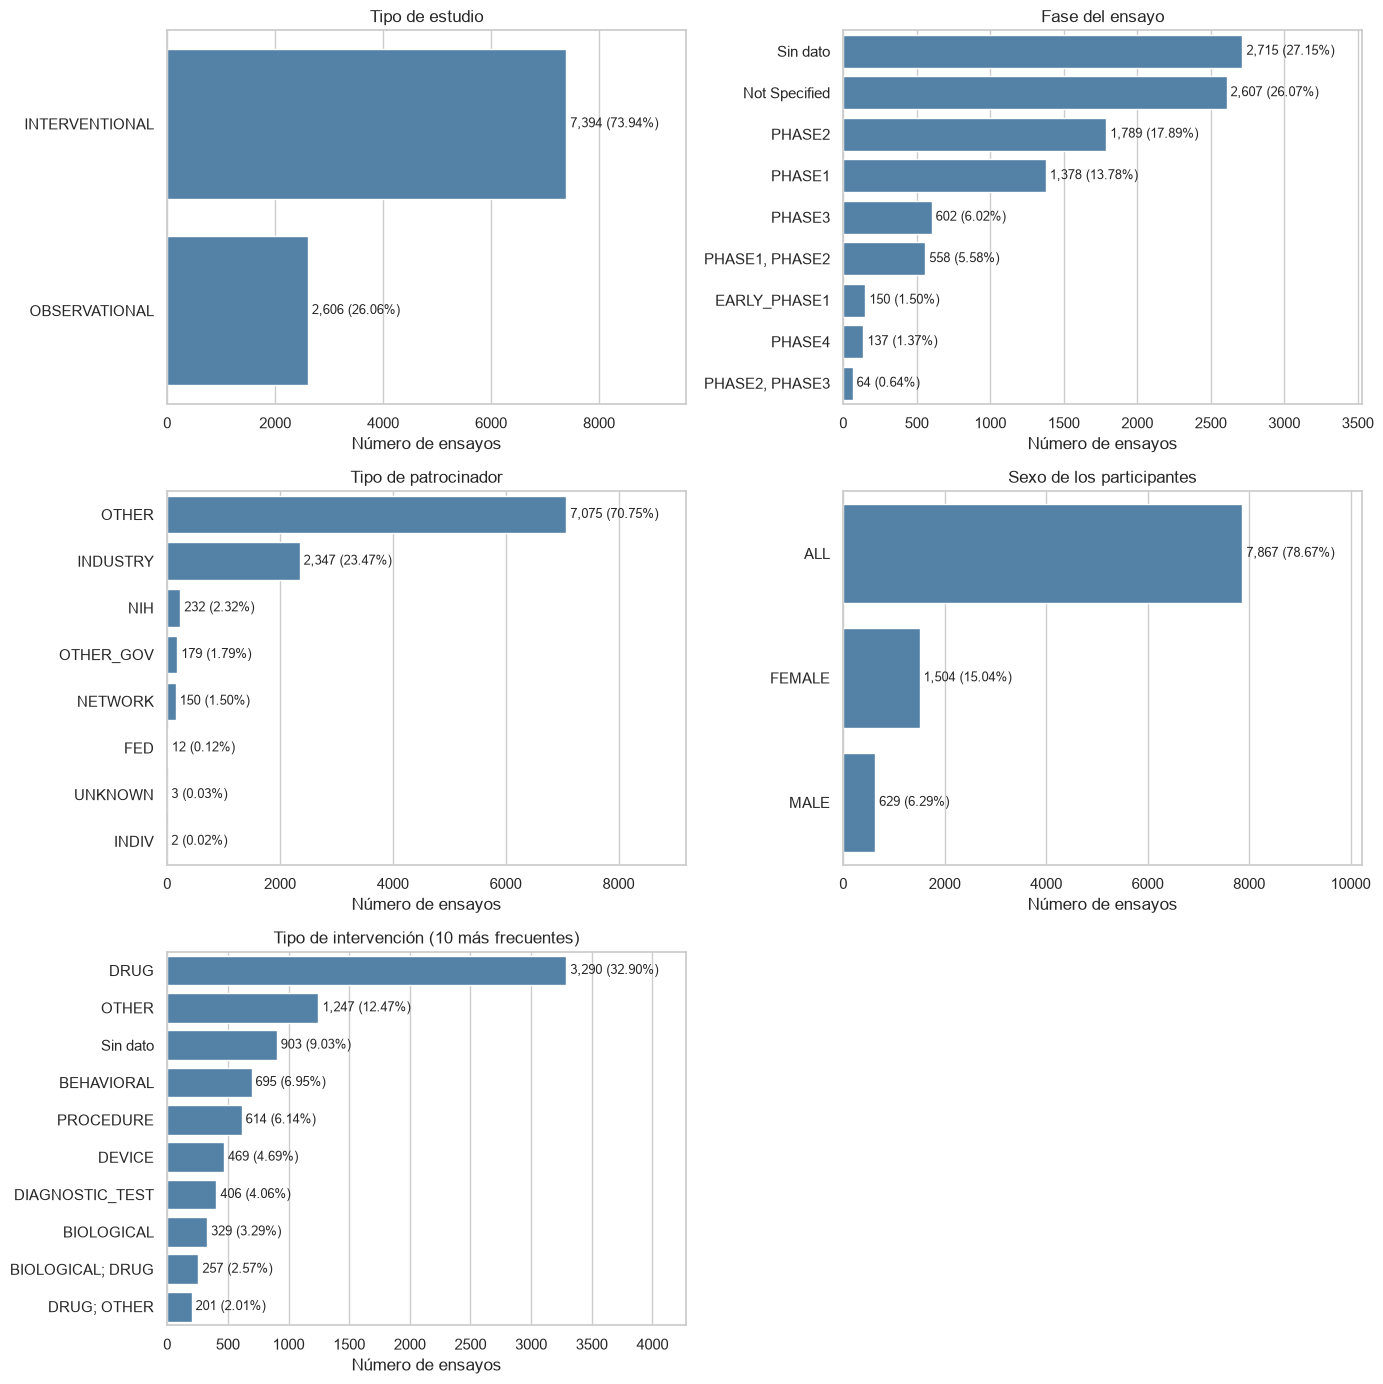

In [19]:
# === 2.4 Distribución de variables categóricas ===

# Variables a graficar y su título en español
variables = {
    "study_type": "Tipo de estudio",
    "phase": "Fase del ensayo",
    "sponsor_type": "Tipo de patrocinador",
    "sex": "Sexo de los participantes",
    "intervention_types": "Tipo de intervención (10 más frecuentes)",
}

# Cuadrícula de 3 filas × 2 columnas (5 gráficas; la sexta posición queda vacía)
fig, ejes = plt.subplots(3, 2, figsize=(14, 14))
ejes = ejes.flatten()

for ax, (col, titulo) in zip(ejes, variables.items()):
    # fillna("Sin dato"): los valores faltantes también se cuentan como una categoría
    conteo = df_cancer[col].fillna("Sin dato").value_counts().head(10)
    sns.barplot(x=conteo.values, y=conteo.index, ax=ax, color="steelblue")

    # Etiqueta con cantidad y porcentaje al final de cada barra
    for i, n in enumerate(conteo.values):
        ax.text(n, i, f" {n:,} ({n / len(df_cancer):.2%})", va="center", fontsize=9)

    ax.set_title(titulo)
    ax.set_xlabel("Número de ensayos")
    ax.set_ylabel("")
    ax.set_xlim(0, conteo.max() * 1.3)  # espacio para las etiquetas

ejes[-1].axis("off")  # ocultar la posición vacía
plt.tight_layout()
plt.show()


Tipo de estudio (study_type): 2 categorías (incluye 'Sin dato')


,ensayos,porcentaje
study_type,,
INTERVENTIONAL,7394,73.94
OBSERVATIONAL,2606,26.06



Fase del ensayo (phase): 9 categorías (incluye 'Sin dato')


,ensayos,porcentaje
phase,,
Sin dato,2715,27.15
Not Specified,2607,26.07
PHASE2,1789,17.89
PHASE1,1378,13.78
PHASE3,602,6.02
"PHASE1, PHASE2",558,5.58
EARLY_PHASE1,150,1.50
PHASE4,137,1.37
"PHASE2, PHASE3",64,0.64



Tipo de patrocinador (sponsor_type): 8 categorías (incluye 'Sin dato')


...

study_type,INTERVENTIONAL,OBSERVATIONAL
phase,,
EARLY_PHASE1,100.00,0.00
Not Specified,0.04,99.96
PHASE1,100.00,0.00
"PHASE1, PHASE2",100.00,0.00
PHASE2,100.00,0.00
"PHASE2, PHASE3",100.00,0.00
PHASE3,100.00,0.00
PHASE4,100.00,0.00
Sin dato,100.00,0.00



Ensayos sin fase ('Sin dato'): 2,715. Tipo de intervención principal:


,ensayos,porcentaje
intervention_types,,
OTHER,719,26.48
BEHAVIORAL,713,26.26
PROCEDURE,425,15.65
DEVICE,325,11.97
DRUG,180,6.63
DIAGNOSTIC_TEST,158,5.82
RADIATION,110,4.05
DIETARY_SUPPLEMENT,44,1.62
BIOLOGICAL,27,0.99



Número de tipos de intervención por ensayo:


,ensayos,porcentaje
intervention_types,,
1,7405,74.05
2,1335,13.35
3,288,2.88
4,51,0.51
5,18,0.18
Sin dato,903,9.03


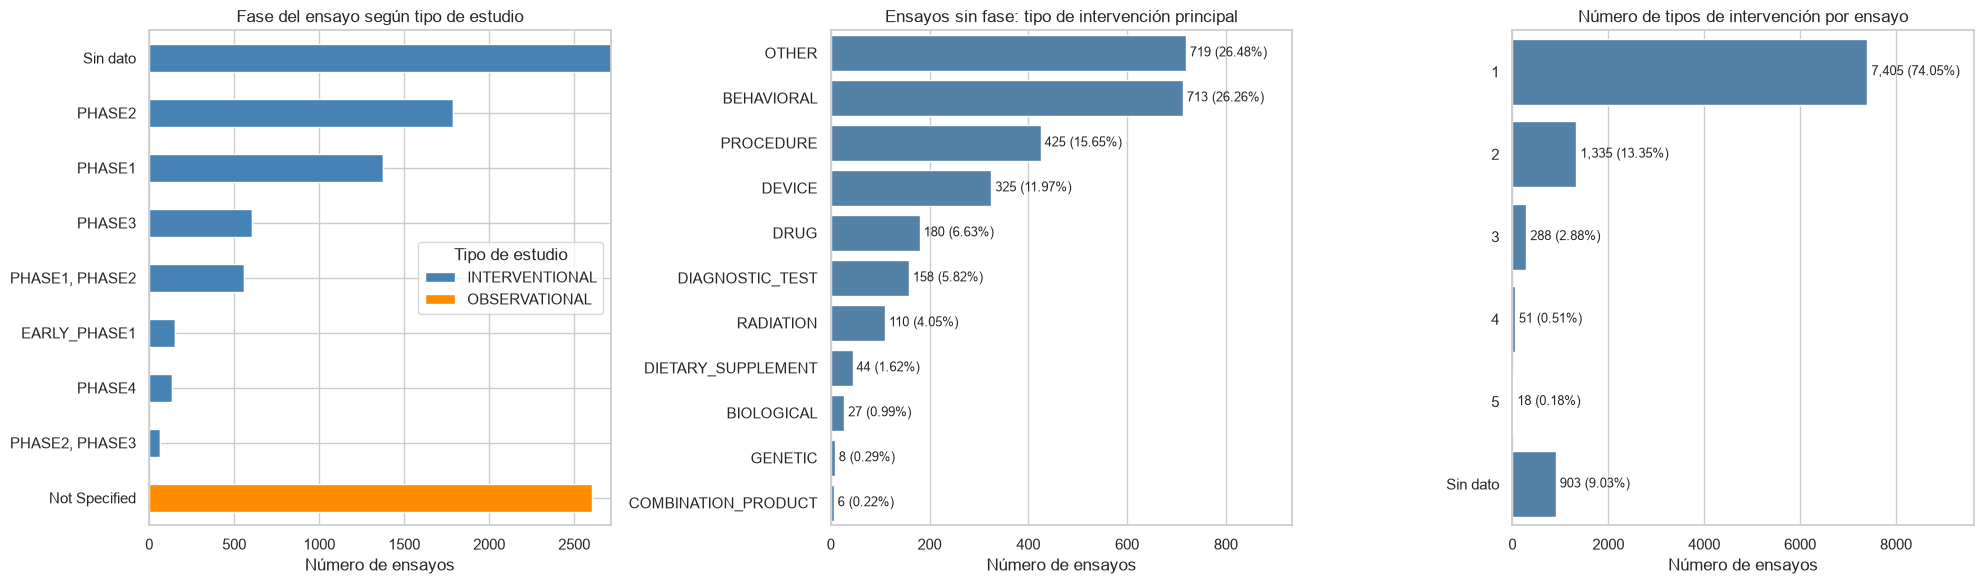

In [20]:
# === 2.4 Tablas de frecuencia y gráficas de apoyo de las variables categóricas ===

def tabla_frecuencias(serie, top=None):
    """Cantidad y porcentaje (2 decimales) de cada categoría, de mayor a menor."""
    tabla = pd.DataFrame({
        "ensayos": serie.value_counts(),
        "porcentaje": serie.value_counts(normalize=True).mul(100).round(2),
    })
    return tabla.head(top) if top else tabla


def graficar_frecuencias(tabla, titulo, ax):
    """Barras horizontales con cantidad y porcentaje a partir de una tabla de frecuencias."""
    sns.barplot(x=tabla["ensayos"], y=tabla.index.astype(str), ax=ax, color="steelblue")
    for i, (n, pct) in enumerate(zip(tabla["ensayos"], tabla["porcentaje"])):
        ax.text(n, i, f" {n:,} ({pct:.2f}%)", va="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel("Número de ensayos")
    ax.set_ylabel("")
    ax.set_xlim(0, tabla["ensayos"].max() * 1.3)  # espacio para las etiquetas


# 1) Frecuencia de cada variable (los faltantes se cuentan como "Sin dato")
for col, titulo in variables.items():
    serie = df_cancer[col].fillna("Sin dato")
    print(f"\n{titulo} ({col}): {serie.nunique()} categorías (incluye 'Sin dato')")
    display(tabla_frecuencias(serie, top=10))

# 2) Fase × tipo de estudio: ¿de dónde vienen "Sin dato" y "Not Specified"?
fase = df_cancer["phase"].fillna("Sin dato")
cruce = pd.crosstab(fase, df_cancer["study_type"])
print("\nFase × tipo de estudio (cantidad):")
display(pd.crosstab(fase, df_cancer["study_type"], margins=True, margins_name="Total"))
print("\nFase × tipo de estudio (% por fila):")
display(pd.crosstab(fase, df_cancer["study_type"], normalize="index").mul(100).round(2))

# 3) Ensayos sin fase: ¿qué tipo de intervención principal tienen?
#    (se toma el primer tipo cuando hay varios separados por ";")
sin_fase = df_cancer["phase"].isna()
tipo_principal = (df_cancer["intervention_types"].fillna("Sin dato")
                  .str.split(";").str[0].str.strip())
tabla_sin_fase = tabla_frecuencias(tipo_principal[sin_fase])
print(f"\nEnsayos sin fase ('Sin dato'): {sin_fase.sum():,}. Tipo de intervención principal:")
display(tabla_sin_fase)

# 4) Tipo de intervención multivalor: ¿cuántos tipos combina cada ensayo?
n_tipos = df_cancer["intervention_types"].str.count(";").add(1)
n_tipos = n_tipos.map(lambda n: "Sin dato" if pd.isna(n) else str(int(n)))
tabla_n_tipos = tabla_frecuencias(n_tipos).sort_index()
print("\nNúmero de tipos de intervención por ensayo:")
display(tabla_n_tipos)

# --- Gráficas de apoyo para los puntos 2, 3 y 4 ---
fig, ejes = plt.subplots(1, 3, figsize=(20, 6))

# Barras apiladas: cuántos ensayos de cada fase son intervencionales u observacionales
cruce.sort_values("INTERVENTIONAL").plot.barh(stacked=True, ax=ejes[0],
                                              color=["steelblue", "darkorange"])
ejes[0].set_title("Fase del ensayo según tipo de estudio")
ejes[0].set_xlabel("Número de ensayos")
ejes[0].set_ylabel("")
ejes[0].legend(title="Tipo de estudio")

graficar_frecuencias(tabla_sin_fase, "Ensayos sin fase: tipo de intervención principal", ejes[1])
graficar_frecuencias(tabla_n_tipos, "Número de tipos de intervención por ensayo", ejes[2])

plt.tight_layout()
plt.show()

**Interpretación: variables categóricas**

- **Fase del ensayo (`phase`):** "Sin dato" (2,715; 27.15%) y "Not Specified" (2,607; 26.07%) no son datos perdidos al azar. El cruce con el tipo de estudio muestra que el 99.96% de "Not Specified" son **estudios observacionales** y el 100% de "Sin dato" son **estudios intervencionales**. Entre estos últimos solo el 6.63% evalúa medicamentos; el resto son intervenciones de otro tipo (26.48%), conductuales (26.26%), procedimientos (15.65%) o dispositivos (11.97%). En ambos casos la fase **no aplica**, porque las fases clínicas son propias de la evaluación de medicamentos. **Decisión preliminar:** no imputar; conservarlos como categorías propias ("No aplica").
- **Tipo de patrocinador (`sponsor_type`):** dominado por OTHER (70.75%) e INDUSTRY (23.47%). FED (12; 0.12%), UNKNOWN (3; 0.03%) e INDIV (2; 0.02%) son **categorías raras**, con muy pocos ensayos para que el modelo aprenda de ellas. **Decisión preliminar:** agruparlas en "Otros".
- **Desbalance:** sexo (ALL = 78.67%), tipo de estudio (intervencional = 73.94%) y tipo de patrocinador (OTHER = 70.75%) tienen una categoría dominante.
- **Tipo de intervención (`intervention_types`):** tiene 138 categorías (incluyendo "Sin dato") porque es **multivalor**: el 74.05% de los ensayos tiene un solo tipo, el 16.92% combina dos o más (por ejemplo, "BIOLOGICAL; DRUG" = producto biológico **y** medicamento) y el 9.03% no tiene dato. DRUG es el tipo más frecuente (32.90%). **Decisión preliminar:** simplificarla en el Paso 3.

### 2.5 Relaciones entre variables

Se analiza la relación de las variables con la duración del ensayo:

- **Variables numéricas:** correlación de **Pearson** (relación lineal, sensible a valores atípicos) y de **Spearman** (relación monótona basada en rangos, robusta a valores atípicos). Además de los participantes, se incluye su logaritmo (base 10) y el año de inicio del ensayo.
- **Variables categóricas:** se compara la distribución de la duración entre categorías con diagramas de caja y tablas de mediana y media por grupo.

Correlación con la duración del ensayo:


,pearson,spearman
participantes,0.011,0.131
log10_participantes,0.201,0.131
anio_inicio,-0.937,-0.882


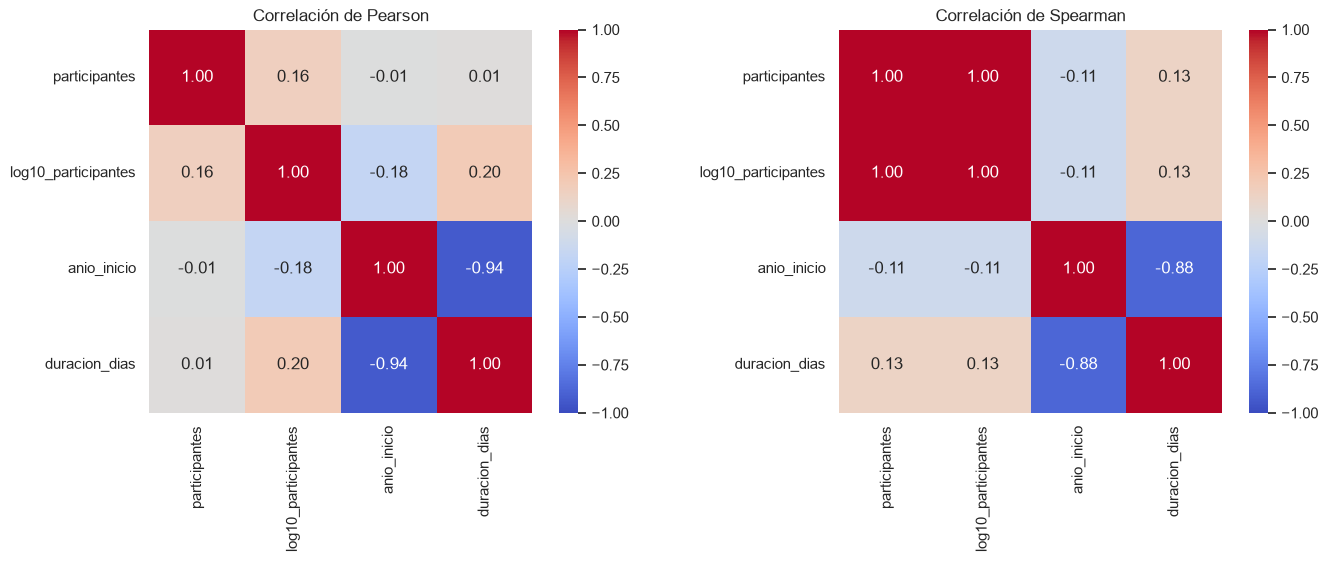

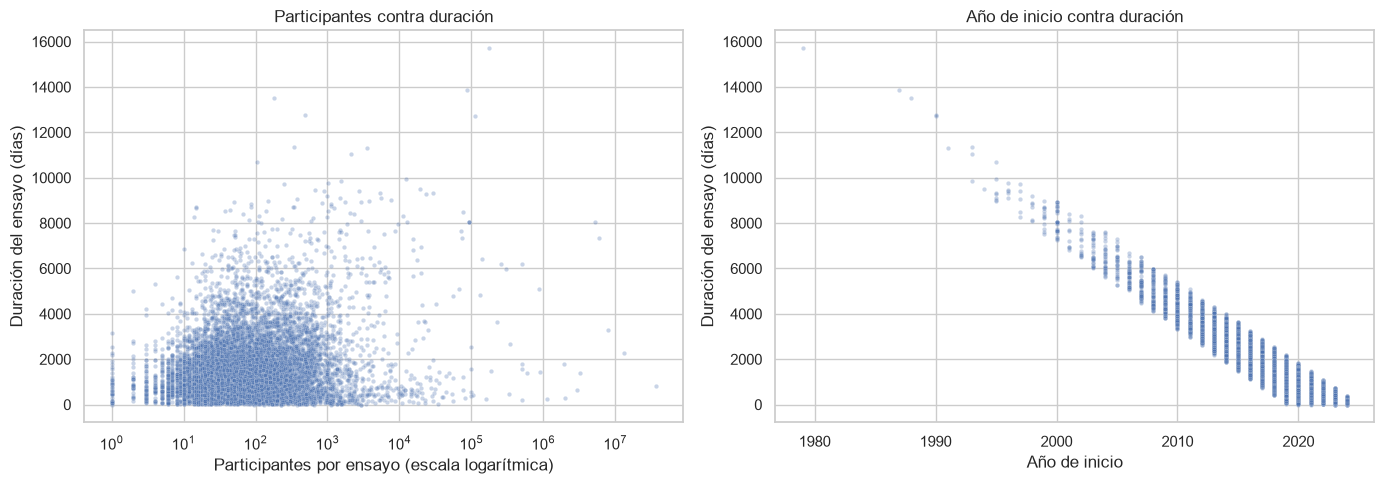


Mediana de participantes por fase:


,mediana_participantes
phase,
PHASE3,358.5
Not Specified,171.0
"PHASE2, PHASE3",120.0
PHASE4,96.0
Sin dato,66.0
PHASE2,50.0
"PHASE1, PHASE2",44.5
PHASE1,26.0
EARLY_PHASE1,16.0


In [23]:
# === 2.5.1 Correlación entre variables numéricas y la duración ===

# Tabla de variables numéricas (temporal, solo para el análisis)
numericas = pd.DataFrame({
    "participantes": df_cancer["enrollment"],
    "log10_participantes": np.log10(df_cancer["enrollment"]),  # mínimo es 1, log10(1) = 0
    "anio_inicio": inicio.dt.year,
    "duracion_dias": duracion_dias,
})

# Matrices de correlación con ambos métodos
pearson = numericas.corr(method="pearson")
spearman = numericas.corr(method="spearman")

# Resumen: correlación de cada variable con la duración
comparacion = pd.DataFrame({
    "pearson": pearson["duracion_dias"],
    "spearman": spearman["duracion_dias"],
}).drop("duracion_dias").round(3)
print("Correlación con la duración del ensayo:")
display(comparacion)

# Mapas de calor de ambas matrices (rojo = positiva, azul = negativa)
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (matriz, metodo) in zip(ejes, [(pearson, "Pearson"), (spearman, "Spearman")]):
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f"Correlación de {metodo}")
plt.tight_layout()
plt.show()

# Diagramas de dispersión para ver la forma de cada relación
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df_cancer["enrollment"], y=duracion_dias, alpha=0.3, s=10, ax=ejes[0])
ejes[0].set_xscale("log")
ejes[0].set_xlabel("Participantes por ensayo (escala logarítmica)")
ejes[0].set_ylabel("Duración del ensayo (días)")
ejes[0].set_title("Participantes contra duración")

sns.scatterplot(x=inicio.dt.year, y=duracion_dias, alpha=0.3, s=10, ax=ejes[1])
ejes[1].set_xlabel("Año de inicio")
ejes[1].set_ylabel("Duración del ensayo (días)")
ejes[1].set_title("Año de inicio contra duración")
plt.tight_layout()
plt.show()


# ¿Las fases más largas también tienen más participantes?
print("\nMediana de participantes por fase:")
display(df_cancer.groupby(df_cancer["phase"].fillna("Sin dato"))["enrollment"]
        .median().sort_values(ascending=False).to_frame("mediana_participantes"))

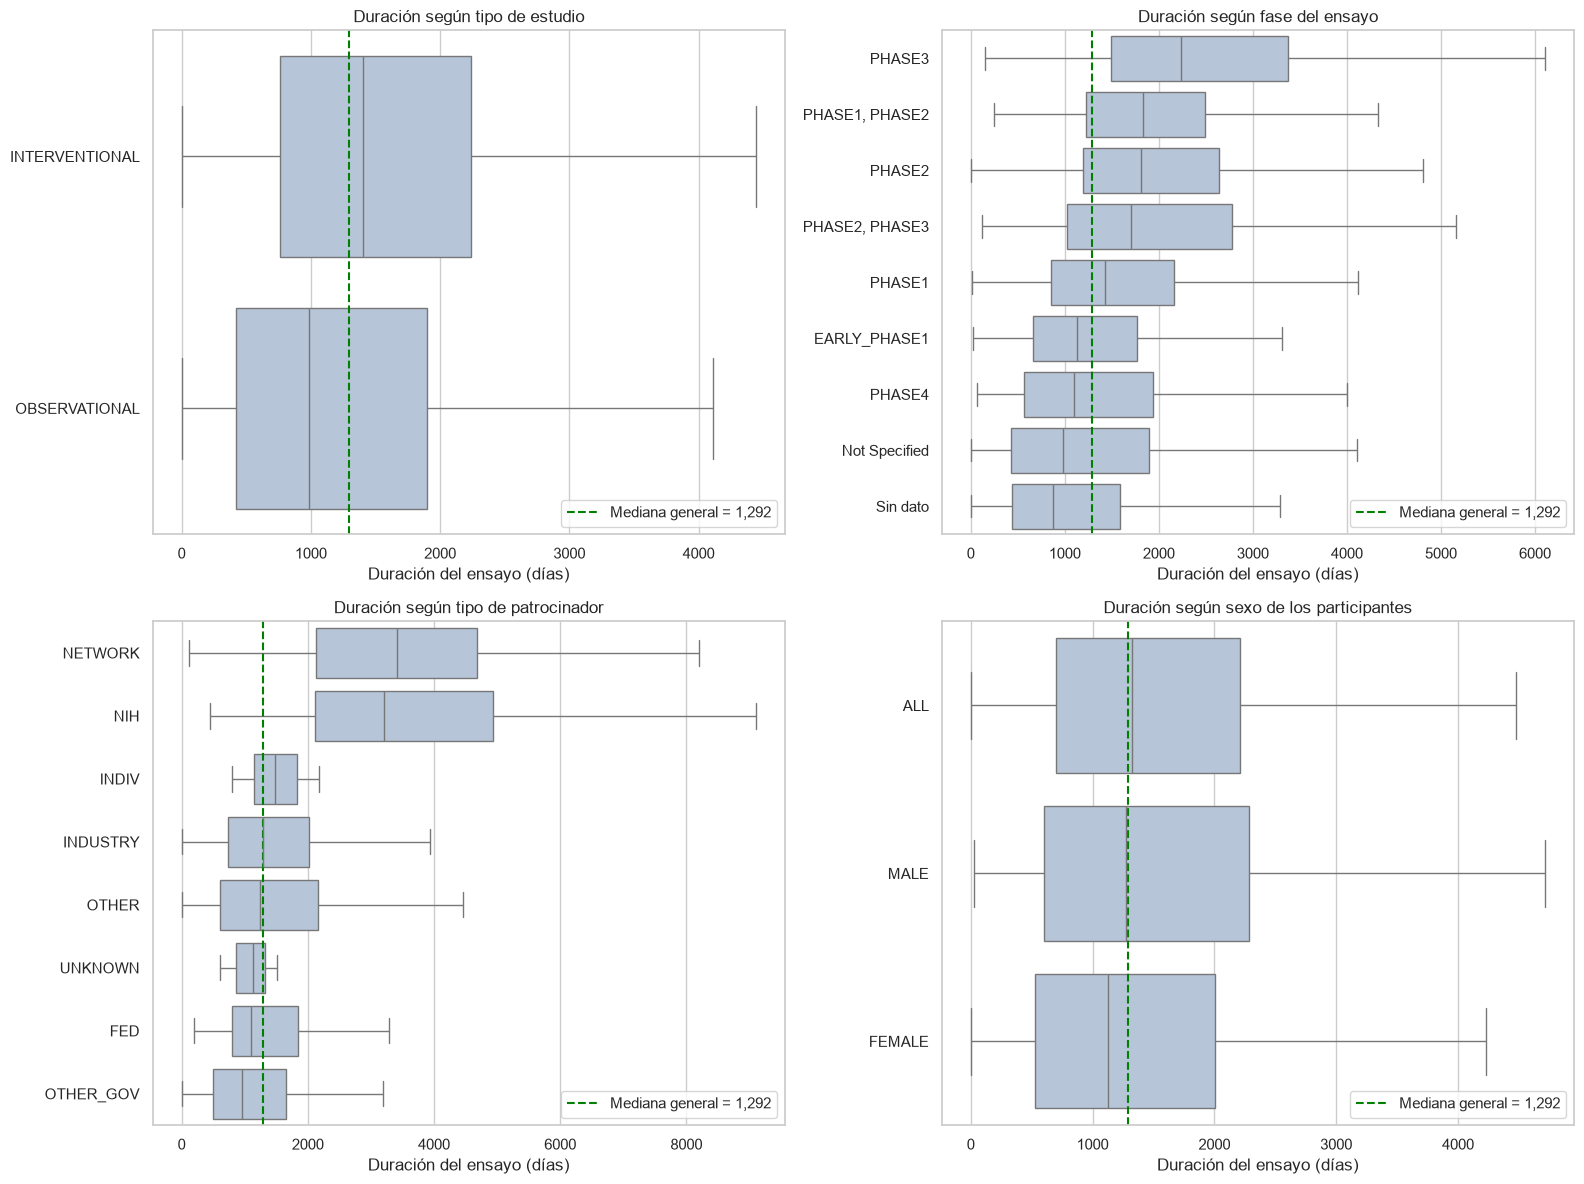


Duración (días) según tipo de estudio (study_type):


,ensayos,mediana,media
study_type,,,
INTERVENTIONAL,7394,1401.0,1681.0
OBSERVATIONAL,2606,984.0,1593.0



Duración (días) según fase del ensayo (phase):


,ensayos,mediana,media
phase,,,
PHASE3,602,2232.0,2603.0
"PHASE1, PHASE2",558,1836.0,2047.0
PHASE2,1789,1812.0,2056.0
"PHASE2, PHASE3",64,1706.0,2090.0
PHASE1,1378,1429.0,1636.0
EARLY_PHASE1,150,1130.0,1318.0
PHASE4,137,1095.0,1423.0
Not Specified,2607,983.0,1592.0
Sin dato,2715,872.0,1200.0



Duración (días) según tipo de patrocinador (sponsor_type):


,ensayos,mediana,media
sponsor_type,,,
NETWORK,150,3416.0,3505.0
NIH,232,3202.0,3810.0
INDIV,2,1485.0,1485.0
INDUSTRY,2347,1282.0,1478.0
OTHER,7075,1246.0,1618.0
UNKNOWN,3,1124.0,1084.0
FED,12,1101.0,1394.0
OTHER_GOV,179,951.0,1273.0



Duración (días) según sexo de los participantes (sex):


,ensayos,mediana,media
sex,,,
ALL,7867,1327.0,1676.0
MALE,629,1278.0,1660.0
FEMALE,1504,1124.0,1563.0



Mediana de participantes por fase:


,mediana_participantes
phase,
PHASE3,358.5
Not Specified,171.0
"PHASE2, PHASE3",120.0
PHASE4,96.0
Sin dato,66.0
PHASE2,50.0
"PHASE1, PHASE2",44.5
PHASE1,26.0
EARLY_PHASE1,16.0


In [24]:
# === 2.5.2 Duración según las variables categóricas ===

variables_relacion = {
    "study_type": "Tipo de estudio",
    "phase": "Fase del ensayo",
    "sponsor_type": "Tipo de patrocinador",
    "sex": "Sexo de los participantes",
}

# Diagramas de caja, ordenados de mayor a menor mediana
# (showfliers=False oculta los valores atípicos para que las cajas sean legibles;
#  ya se cuantificaron en 2.3)
fig, ejes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (col, titulo) in zip(ejes.flatten(), variables_relacion.items()):
    categoria = df_cancer[col].fillna("Sin dato")
    orden = duracion_dias.groupby(categoria).median().sort_values(ascending=False).index
    sns.boxplot(x=duracion_dias, y=categoria, order=orden, ax=ax,
                color="lightsteelblue", showfliers=False)
    ax.axvline(duracion_dias.median(), color="green", linestyle="--",
               label=f"Mediana general = {duracion_dias.median():,.0f}")
    ax.set_title(f"Duración según {titulo.lower()}")
    ax.set_xlabel("Duración del ensayo (días)")
    ax.set_ylabel("")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Tablas con las cifras exactas: número de ensayos, mediana y media por categoría
for col, titulo in variables_relacion.items():
    categoria = df_cancer[col].fillna("Sin dato")
    resumen = (duracion_dias.groupby(categoria)
               .agg(ensayos="count", mediana="median", media="mean")
               .round(0).sort_values("mediana", ascending=False))
    print(f"\nDuración (días) según {titulo.lower()} ({col}):")
    display(resumen)

# ¿Las fases más largas también tienen más participantes?
print("\nMediana de participantes por fase:")
display(df_cancer.groupby(df_cancer["phase"].fillna("Sin dato"))["enrollment"]
        .median().sort_values(ascending=False).to_frame("mediana_participantes"))

**Interpretación: relaciones con la duración**

- **Participantes:** la correlación de Pearson es prácticamente nula (0.011) porque unos pocos ensayos con millones de participantes dominan el cálculo. Con el logaritmo de los participantes aumenta a 0.201, y Spearman da 0.131 en ambos casos (el logaritmo no cambia el orden de los valores). Existe una **relación positiva débil**: los ensayos con más participantes tienden a durar algo más. Esto **confirma la conveniencia de la transformación logarítmica** propuesta en 2.2.
- **Año de inicio (fuga de información):** la correlación es muy fuerte (Pearson −0.937; Spearman −0.882) y el diagrama de dispersión forma casi una línea recta. Esto no es una relación útil, sino una consecuencia de cómo se construyó el conjunto de datos: como todas las fechas de término están entre 2020 y 2024, el año de inicio prácticamente **determina** la duración. Usarlo como predictor sería una **fuga de información** (*data leakage*): el modelo obtendría la respuesta en lugar de aprenderla. **Decisión:** el año de inicio **no se usará** como predictor.
- **Tipo de estudio:** los intervencionales duran más (mediana de 1,401 días) que los observacionales (984 días).
- **Fase del ensayo:** es la variable categórica con mayor diferencia entre grupos. La Fase 3 es la más larga (mediana de 2,232 días, ≈ 6 años), seguida de las Fases 1-2 (1,836) y 2 (1,812); los ensayos sin fase son los más cortos ("Not Specified" = 983; "Sin dato" = 872). La Fase 3 también es la que tiene más participantes (mediana de 358.5, contra 50 en Fase 2 y 26 en Fase 1), lo que es consistente con la relación positiva entre participantes y duración observada en 2.5.1.
- **Tipo de patrocinador:** NETWORK (3,416 días) y NIH (3,202 días) duran unas 2.5 veces la mediana general (1,292 días); INDUSTRY (1,282) está en la mediana general. Las medianas de INDIV (2 ensayos), UNKNOWN (3) y FED (12) no son confiables por su tamaño, lo que **refuerza la decisión de agruparlas**.
- **Sexo de los participantes:** las diferencias son pequeñas (ALL = 1,327; MALE = 1,278; FEMALE = 1,124 días) y sus diagramas de caja se traslapan casi por completo, por lo que se espera que aporte poco al modelo.

## 3. Limpieza de datos

Se aplican sobre una copia del dataframe (`df`) las decisiones tomadas en el EDA. Cada decisión se registra en una **bitácora** con el número de registros afectados, para que el proceso sea trazable y auditable.

| Problema | Decisión | Justificación (sección del EDA) |
|---|---|---|
| Duplicados | Verificar filas e IDs repetidos | Requisito de calidad |
| Tipos incorrectos | Convertir fechas de texto a fecha; día 1 cuando falta el día | 2.3: error máximo ≈ 2% de la duración mediana |
| Variable objetivo | `duracion_dias` = término − inicio | 2.3 |
| Valores atípicos (duración) | Eliminar los ensayos de 0 días | 2.3: no representan una duración real |
| Valores atípicos (participantes) | Conservarlos y aplicar logaritmo base 10 | 2.2 y 2.5: estudios reales; el logaritmo mejora la correlación |
| Valores faltantes (fase) | NaN y "Not Specified" → "No aplica" (sin imputar) | 2.4: la fase no aplica a esos estudios |
| Valores faltantes y multivalor (intervención) | Una columna binaria (0/1) por tipo de intervención | 2.4: el 16.92% combina varios tipos |
| Categorías raras (patrocinador) | FED, UNKNOWN e INDIV → MINORITARIOS | 2.4 y 2.5: muy pocos ensayos |
| Selección de variables | Excluir identificador, texto libre, constante, alta cardinalidad y fechas | 1.4 y 2.5 (fuga de información del año de inicio) |

La codificación One-Hot-Encoder de las variables categóricas se realiza en el Paso 4, dentro del flujo del modelo, para ajustarla **solo con los datos de entrenamiento**.

In [25]:
# === 3. Limpieza de datos ===

# Copia de trabajo: df_cancer (original) no se modifica
df = df_cancer.copy()

# Bitácora: registro de cada decisión y cuántos registros afectó (trazabilidad)
bitacora = []
def registrar(paso, decision, afectados):
    bitacora.append({"paso": paso, "decisión": decision, "registros afectados": afectados})


# --- 3.1 Duplicados ---
dup_total = df.duplicated().sum()                          # filas idénticas
dup_sin_id = df.drop(columns="nct_id").duplicated().sum()  # idénticas salvo el ID
dup_id = df["nct_id"].duplicated().sum()                   # ID repetido
print(f"Duplicados: filas idénticas = {dup_total} | idénticas sin ID = {dup_sin_id} | ID repetido = {dup_id}")
registrar("3.1 Duplicados", "Verificar filas e IDs duplicados (no se encontraron)", int(dup_total + dup_sin_id + dup_id))


# --- 3.2 Tipos incorrectos: fechas de texto a tipo fecha ---
# Ensayos con al menos una fecha sin día (formato AAAA-MM)
n_sin_dia = int(((df["start_date"].str.len() == 7) | (df["completion_date"].str.len() == 7)).sum())
df["start_date"] = pd.to_datetime(df["start_date"], format="mixed")       # AAAA-MM → día 1
df["completion_date"] = pd.to_datetime(df["completion_date"], format="mixed")
registrar("3.2 Tipos incorrectos", "Convertir fechas de texto a fecha; a las fechas sin día (AAAA-MM) se les asigna el día 1", n_sin_dia)


# --- 3.3 Variable objetivo: duración en días ---
df["duracion_dias"] = (df["completion_date"] - df["start_date"]).dt.days
registrar("3.3 Variable objetivo", "Crear duracion_dias = completion_date − start_date", len(df))


# --- 3.4 Valores atípicos ---
# Duración de 0 días: no representa una duración real → se eliminan
cero = df["duracion_dias"] == 0
df = df[~cero]
registrar("3.4 Valores atípicos", "Eliminar ensayos con duración de 0 días", int(cero.sum()))

# Participantes: los valores extremos son estudios reales → se conservan,
# pero se transforma con logaritmo base 10 para reducir el sesgo
df["log10_participantes"] = np.log10(df["enrollment"])
registrar("3.4 Valores atípicos", "Conservar valores extremos de participantes y crear log10_participantes", len(df))


# --- 3.5 Valores faltantes ---
# Fase: "Sin dato" (NaN) y "Not Specified" significan que la fase NO APLICA → no se imputa
n_fase = int(df["phase"].isna().sum() + (df["phase"] == "Not Specified").sum())
df["phase"] = df["phase"].fillna("No aplica").replace("Not Specified", "No aplica")
registrar("3.5 Valores faltantes", "Fase: NaN y 'Not Specified' → categoría 'No aplica' (sin imputar)", n_fase)

# Tipo de intervención: variable multivalor → una columna binaria (0/1) por tipo.
# Los tipos poco frecuentes se agrupan en OTHER; los faltantes quedan con todas en 0
# más una columna que indica "sin dato"
tipos_frecuentes = ["DRUG", "OTHER", "PROCEDURE", "BEHAVIORAL", "BIOLOGICAL",
                    "DEVICE", "RADIATION", "DIAGNOSTIC_TEST"]
tipos = df["intervention_types"].str.split(";").apply(
    lambda lista: {t.strip() for t in lista} if isinstance(lista, list) else set())
for t in tipos_frecuentes:
    df[f"interv_{t.lower()}"] = tipos.apply(lambda s: int(t in s))
raros = tipos.apply(lambda s: int(bool(s - set(tipos_frecuentes))))  # DIETARY_SUPPLEMENT, COMBINATION_PRODUCT, GENETIC
df["interv_other"] = df["interv_other"] | raros
df["interv_sin_dato"] = df["intervention_types"].isna().astype(int)
registrar("3.5 Valores faltantes", "Tipo de intervención: columnas binarias por tipo; tipos raros → OTHER; faltantes → interv_sin_dato", int(df["interv_sin_dato"].sum()))


# --- 3.6 Categorías raras ---
raras = ["FED", "UNKNOWN", "INDIV"]
n_raras = int(df["sponsor_type"].isin(raras).sum())
df["sponsor_type"] = df["sponsor_type"].replace(raras, "MINORITARIOS")
registrar("3.6 Categorías raras", "Patrocinador: FED, UNKNOWN e INDIV → MINORITARIOS", n_raras)


# --- 3.7 Selección de variables ---
# Se excluyen: identificador, texto libre, constante, alta cardinalidad,
# fechas (ya usadas para la variable objetivo; el año de inicio sería fuga de información)
# y los participantes sin transformar
excluidas = ["nct_id", "study_title", "study_status", "conditions", "interventions",
             "lead_sponsor", "intervention_types", "start_date", "completion_date", "enrollment"]
df = df.drop(columns=excluidas)
registrar("3.7 Selección de variables", f"Excluir {len(excluidas)} columnas sin valor predictivo o con fuga de información", len(excluidas))


# --- Resultado final ---
print(f"\nRegistros: {len(df_cancer):,} → {len(df):,}  |  Variables: {df_cancer.shape[1]} → {df.shape[1]}")
print(f"Valores faltantes restantes: {df.isna().sum().sum()}")
print(f"Duración mínima: {df['duracion_dias'].min()} días | máxima: {df['duracion_dias'].max():,} días")
display(pd.DataFrame(bitacora))
df.info()
display(df.head())

Duplicados: filas idénticas = 0 | idénticas sin ID = 0 | ID repetido = 0

Registros: 10,000 → 9,991  |  Variables: 14 → 15
Valores faltantes restantes: 0
Duración mínima: 3 días | máxima: 15,705 días


,paso,decisión,registros afectados
0,3.1 Duplicados,Verificar filas e IDs duplicados (no se encont...,0
1,3.2 Tipos incorrectos,Convertir fechas de texto a fecha; a las fecha...,1139
2,3.3 Variable objetivo,Crear duracion_dias = completion_date − start_...,10000
3,3.4 Valores atípicos,Eliminar ensayos con duración de 0 días,9
4,3.4 Valores atípicos,Conservar valores extremos de participantes y ...,9991
5,3.5 Valores faltantes,Fase: NaN y 'Not Specified' → categoría 'No ap...,5314
6,3.5 Valores faltantes,Tipo de intervención: columnas binarias por ti...,902
7,3.6 Categorías raras,"Patrocinador: FED, UNKNOWN e INDIV → MINORITARIOS",17
8,3.7 Selección de variables,Excluir 10 columnas sin valor predictivo o con...,10


<class 'pandas.DataFrame'>
Index: 9991 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   study_type              9991 non-null   str    
 1   phase                   9991 non-null   str    
 2   sponsor_type            9991 non-null   str    
 3   sex                     9991 non-null   str    
 4   duracion_dias           9991 non-null   int64  
 5   log10_participantes     9991 non-null   float64
 6   interv_drug             9991 non-null   int64  
 7   interv_other            9991 non-null   int64  
 8   interv_procedure        9991 non-null   int64  
 9   interv_behavioral       9991 non-null   int64  
 10  interv_biological       9991 non-null   int64  
 11  interv_device           9991 non-null   int64  
 12  interv_radiation        9991 non-null   int64  
 13  interv_diagnostic_test  9991 non-null   int64  
 14  interv_sin_dato         9991 non-null   int64  
dtypes: 

,study_type,phase,sponsor_type,sex,duracion_dias,log10_participantes,interv_drug,interv_other,interv_procedure,interv_behavioral,interv_biological,interv_device,interv_radiation,interv_diagnostic_test,interv_sin_dato
0,INTERVENTIONAL,PHASE2,INDUSTRY,ALL,1934,1.740363,1,0,0,0,0,0,0,0,0
1,INTERVENTIONAL,PHASE2,INDUSTRY,ALL,841,1.414973,1,0,0,0,0,0,0,0,0
2,INTERVENTIONAL,No aplica,OTHER,ALL,1079,1.204120,0,1,1,0,0,1,0,0,0
3,INTERVENTIONAL,No aplica,INDUSTRY,ALL,1632,1.447158,1,0,0,0,0,1,0,0,0
4,INTERVENTIONAL,PHASE2,OTHER,FEMALE,2395,1.447158,1,0,0,0,0,0,0,0,0


**Resultado de la limpieza**

- **Registros:** de 10,000 a **9,991**; solo se eliminaron los 9 ensayos con duración de 0 días (0.09%). No se encontraron duplicados.
- **Variables:** de 14 a **15**, todas sin valores faltantes:
  - **Variable objetivo:** `duracion_dias` (mínimo 3 días, máximo 15,705 días).
  - **4 categóricas:** tipo de estudio, fase, tipo de patrocinador y sexo.
  - **1 numérica:** `log10_participantes`.
  - **9 binarias** de tipo de intervención (`interv_*`), incluida `interv_sin_dato` (902 ensayos).
- **Fechas:** 1,139 ensayos tenían al menos una fecha sin día y se les asignó el día 1.
- **Fase:** 5,314 ensayos quedaron en la categoría "No aplica". Este valor es **información**, no un dato faltante.
- **Patrocinador:** 17 ensayos se agruparon en MINORITARIOS.
- Se excluyeron 10 columnas, entre ellas las fechas, para evitar la **fuga de información** detectada en 2.5.

### 3.8 Registro de la preparación de datos en MLflow

La limpieza se registra como una ejecución propia (`01_preparacion_datos`) dentro del experimento, para dejar evidencia del **linaje de los datos**: qué datos entraron (con su huella digital o *digest*), qué decisiones se aplicaron, cuántos registros afectó cada una y qué datos resultaron. El modelo base (Paso 6) se registrará en una segunda ejecución ligada a esta.

In [26]:
# === 3.8 Registro de la preparación de datos en MLflow ===
import os
import tempfile

# Configuración de MLflow: base de datos local (SQLite) en la carpeta del proyecto
mlflow.set_tracking_uri("sqlite:///mlflow.db")
EXPERIMENTO = "TC5061_Semana3_Baseline_DuracionEnsayos"
mlflow.set_experiment(EXPERIMENTO)

with mlflow.start_run(run_name="01_preparacion_datos") as run_datos:
    mlflow.set_tags({"etapa": "preparacion_datos", "autor": "Roberto Robles"})

    # 1) Linaje de datos: conjunto original y conjunto limpio (MLflow calcula su huella digital)
    ds_original = mlflow.data.from_pandas(df_cancer, source=DATA_PATH, name="cancer_trials_original")
    ds_limpio = mlflow.data.from_pandas(df, source=DATA_PATH, name="cancer_trials_limpio",
                                        targets="duracion_dias")
    mlflow.log_input(ds_original, context="original")
    mlflow.log_input(ds_limpio, context="limpio")

    # 2) Decisiones de limpieza (parámetros)
    mlflow.log_params({
        "fechas_sin_dia": "se asigna el dia 1 del mes",
        "duracion_cero": "se eliminan",
        "participantes_atipicos": "se conservan + log10",
        "fase_faltante": "No aplica (sin imputar)",
        "tipo_intervencion": "columnas binarias por tipo",
        "patrocinadores_agrupados": ", ".join(raras) + " -> MINORITARIOS",
        "columnas_excluidas": ", ".join(excluidas),
    })

    # 3) Conteos de la limpieza (métricas)
    mlflow.log_metrics({
        "registros_originales": len(df_cancer),
        "registros_finales": len(df),
        "registros_eliminados": int(cero.sum()),
        "duplicados": int(dup_total + dup_sin_id + dup_id),
        "ensayos_fecha_sin_dia": n_sin_dia,
        "ensayos_fase_no_aplica": n_fase,
        "ensayos_intervencion_sin_dato": int(df["interv_sin_dato"].sum()),
        "ensayos_patrocinador_agrupado": n_raras,
        "variables_finales": df.shape[1],
    })

    # 4) Artefactos: bitácora, datos limpios y entorno
    mlflow.log_table(pd.DataFrame(bitacora), artifact_file="bitacora_limpieza.json")
    with tempfile.TemporaryDirectory() as carpeta_temp:
        ruta = os.path.join(carpeta_temp, "datos_limpios.csv")
        df.to_csv(ruta, index=False)
        mlflow.log_artifact(ruta, artifact_path="datos")
    mlflow.log_artifact("requirements-lock.txt", artifact_path="entorno")

    # Se guarda el ID de esta ejecución para ligarla con la del modelo (Paso 6)
    RUN_ID_DATOS = run_datos.info.run_id

print(f"Experimento : {EXPERIMENTO}")
print(f"Ejecución   : 01_preparacion_datos (run_id = {RUN_ID_DATOS})")
print(f"Huella digital del conjunto original: {ds_original.digest}")
print(f"Huella digital del conjunto limpio  : {ds_limpio.digest}")

2026/10/01 09:08:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/01 09:08:05 INFO mlflow.store.db.utils: Updating database tables
2026/10/01 09:08:05 INFO mlflow.tracking.fluent: Experiment with name 'TC5061_Semana3_Baseline_DuracionEnsayos' does not exist. Creating a new experiment.
/Users/Roberto/Library/CloudStorage/Dropbox/ITESM - Maestría IA/Cursos/Trim3 - Operaciones de Aprendizaje Automático/Semana 3/Actividad/.venv/lib/python3.13/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/Users/Roberto/Library/CloudStorage/Dropbox/ITESM - Maestría IA/Cursos/Trim3 - Operaciones de Aprendizaje Automático/Semana 3/Actividad/.venv/lib/python3.13/site-packages/mlflow/data/dataset_source_registry.py:148: 

Experimento : TC5061_Semana3_Baseline_DuracionEnsayos
Ejecución   : 01_preparacion_datos (run_id = 9b4cbae075404df482854ac816524113)
Huella digital del conjunto original: 0be08fe6
Huella digital del conjunto limpio  : 5c86b1e2


/Users/Roberto/Library/CloudStorage/Dropbox/ITESM - Maestría IA/Cursos/Trim3 - Operaciones de Aprendizaje Automático/Semana 3/Actividad/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


**Evidencia en MLflow: ejecución `01_preparacion_datos`**

*Figura 1. Resumen de la ejecución `01_preparacion_datos`: estado, datos de entrada y etiquetas.*

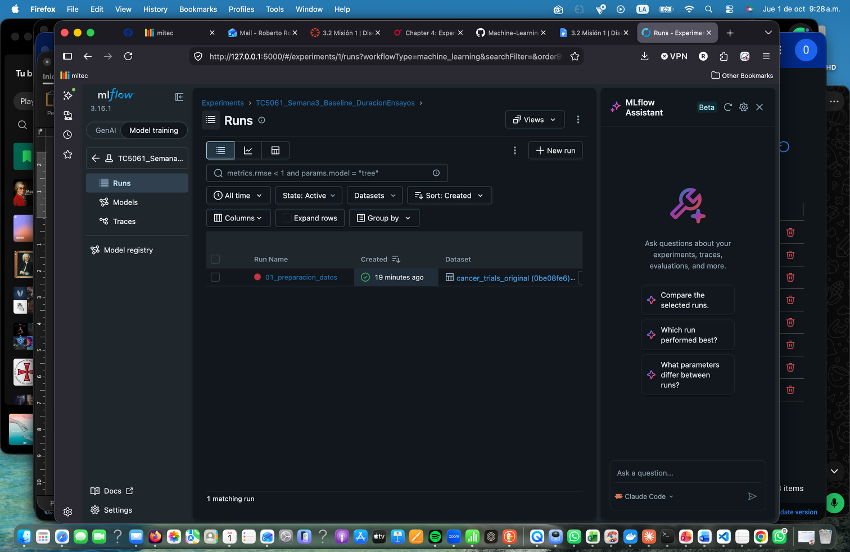


*Figura 2. Métricas (conteos) y parámetros (decisiones) de la limpieza.*

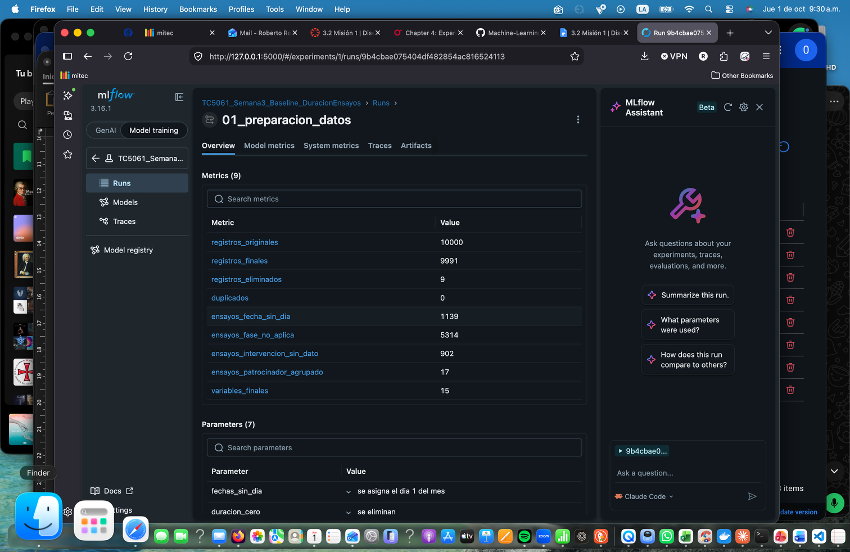

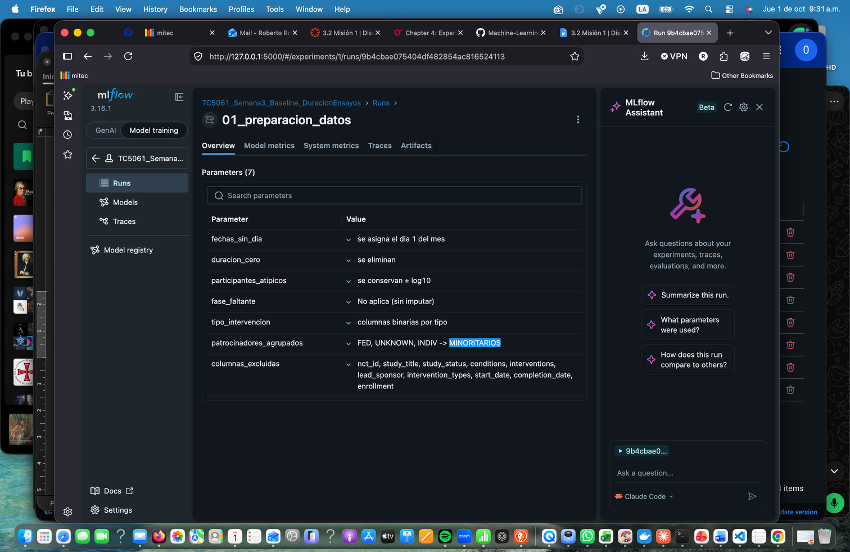

*Figura 3. Linaje de datos: conjunto original (10,000 registros, huella `0be08fe6`) y conjunto limpio (9,991 registros, huella `5c86b1e2`), con sus esquemas.*

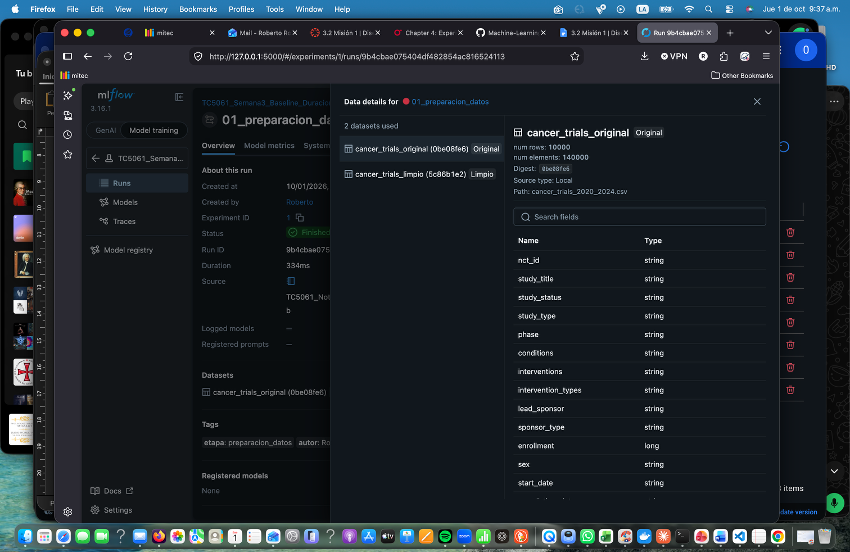

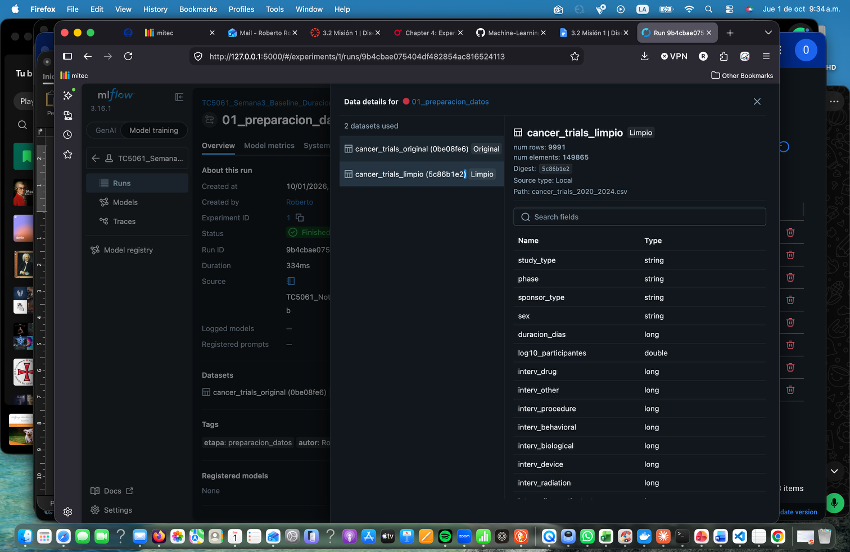

*Figura 4. Bitácora de limpieza registrada como artefacto.*

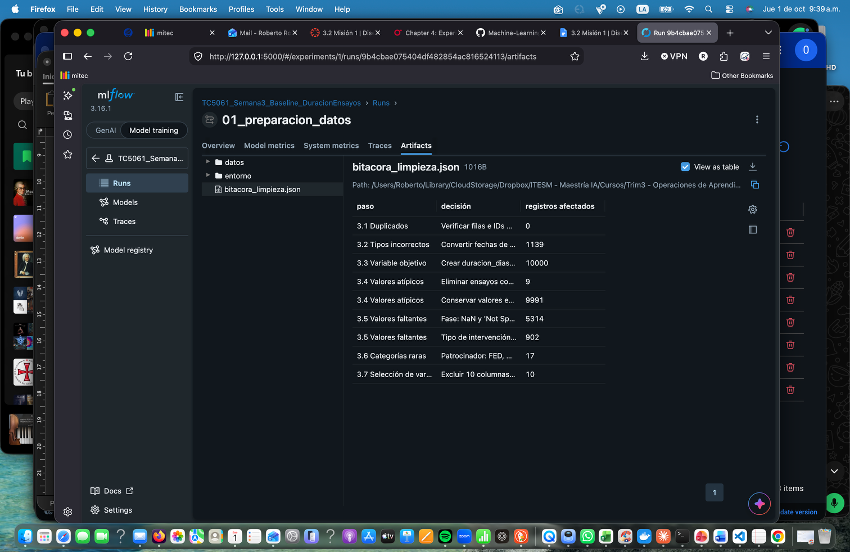

## 4. Modelo base

Se entrena una **regresión lineal** como modelo base: es el modelo más simple e interpretable para un problema de regresión, y sirve como punto de partida para comparar modelos más complejos en el futuro.

- **División:** 80% entrenamiento y 20% prueba, con semilla fija (`SEED = 42`) para que sea reproducible. No se usa un conjunto de validación separado porque la regresión lineal no tiene hiperparámetros que ajustar; en su lugar, en el Paso 5 se aplica **validación cruzada de 5 pliegues** sobre el entrenamiento para medir la estabilidad del modelo sin tocar el conjunto de prueba.
- **Flujo del modelo (`Pipeline`):** codificación one-hot de las 4 variables categóricas + regresión lineal. El codificador se ajusta solo con los datos de entrenamiento, para evitar fuga de información.
- **Modelo de referencia:** un `DummyRegressor` que siempre predice la mediana de entrenamiento. Si la regresión lineal no lo supera, no está aprendiendo nada útil.

In [27]:
# === 4. Modelo base ===
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

# --- 4.1 Variables predictoras (X) y variable objetivo (y) ---
OBJETIVO = "duracion_dias"
CATEGORICAS = ["study_type", "phase", "sponsor_type", "sex"]  # se codifican con one-hot-encoder
X = df.drop(columns=OBJETIVO)
y = df[OBJETIVO]

# --- 4.2 División en entrenamiento (80%) y prueba (20%) ---
# random_state=SEED garantiza que la división sea siempre la misma (reproducibilidad)
TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED)
print(f"Entrenamiento: {len(X_train):,} registros | Prueba: {len(X_test):,} registros")

# --- 4.3 Flujo del modelo (Pipeline): codificación one-hot + regresión lineal ---
# El codificador se ajusta solo con los datos de entrenamiento al llamar a fit(),
# así no se filtra información del conjunto de prueba.
#   drop="first": elimina una categoría de referencia por variable (evita colinealidad)
#   handle_unknown="ignore": si en prueba aparece una categoría no vista, no falla
preprocesamiento = ColumnTransformer(
    transformers=[("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAS)],
    remainder="passthrough",  # log10_participantes y columnas interv_* pasan sin cambios
)
modelo = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("regresion", LinearRegression()),
])
modelo.fit(X_train, y_train)

# --- 4.4 Modelo de referencia: siempre predice la mediana del entrenamiento ---
# Sirve para saber si la regresión lineal realmente aprende algo
referencia = DummyRegressor(strategy="median")
referencia.fit(X_train, y_train)

print(f"Variables después de la codificación: {len(modelo.named_steps['preprocesamiento'].get_feature_names_out())}")
print(f"Predicción del modelo de referencia: {referencia.predict(X_test[:1])[0]:,.0f} días para todos los ensayos")

Entrenamiento: 7,992 registros | Prueba: 1,999 registros
Variables después de la codificación: 25
Predicción del modelo de referencia: 1,294 días para todos los ensayos


## 5. Evaluación del modelo

Al ser un problema de regresión, se usan tres métricas, calculadas en entrenamiento y en prueba para ambos modelos, y con validación cruzada de 5 pliegues para la regresión lineal:

- **MAE** (error absoluto medio): en promedio, cuántos días se equivoca el modelo. 
- **RMSE** (raíz del error cuadrático medio): también en días, pero penaliza más los errores grandes.
- **R²** (coeficiente de determinación): proporción de la variabilidad de la duración que explica el modelo (1 = perfecto, 0 = igual que predecir la media).

MAE      RMSE     R2
Referencia (mediana) Entrenamiento  999.004  1489.657 -0.065
                     Prueba         988.706  1517.711 -0.058
Regresión lineal     Entrenamiento  891.602  1269.901  0.226
                     Prueba         884.730  1294.761  0.230

Mejora del MAE frente a la referencia: 10.5%
Validación cruzada de 5 pliegues (regresión lineal, entrenamiento):


,MAE,RMSE,R2
Pliegue 1,905.588,1277.098,0.214
Pliegue 2,875.027,1224.570,0.232
Pliegue 3,854.633,1225.458,0.212
Pliegue 4,956.632,1404.512,0.216
Pliegue 5,879.658,1231.489,0.228
Media,894.308,1272.625,0.220
Desviación estándar,39.281,76.877,0.009


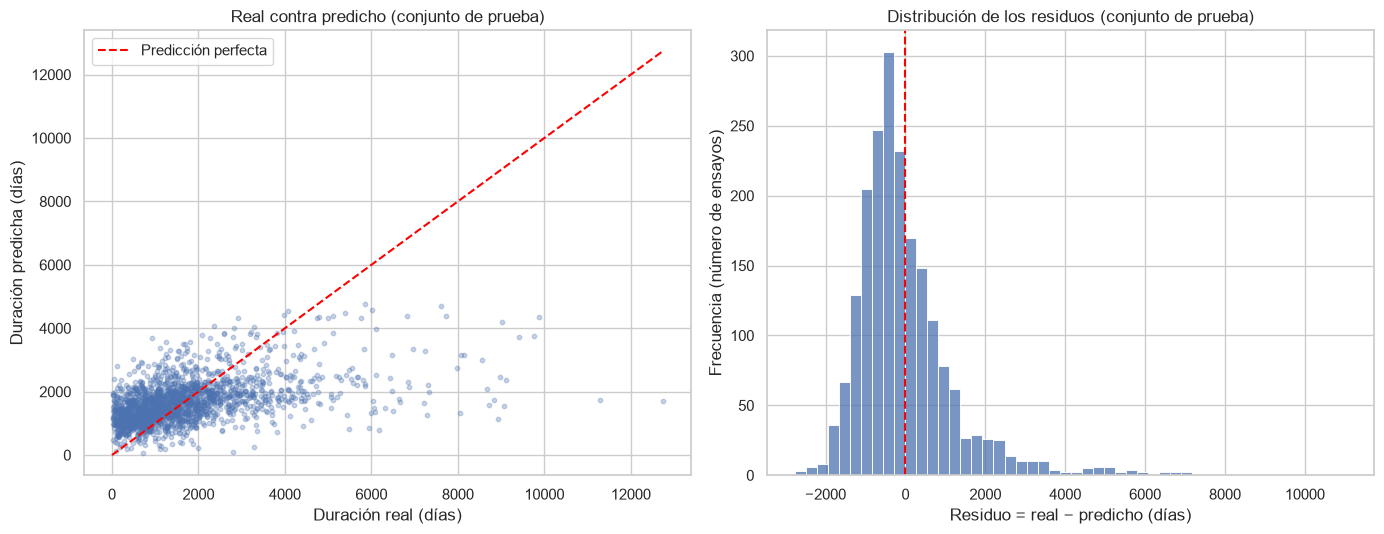

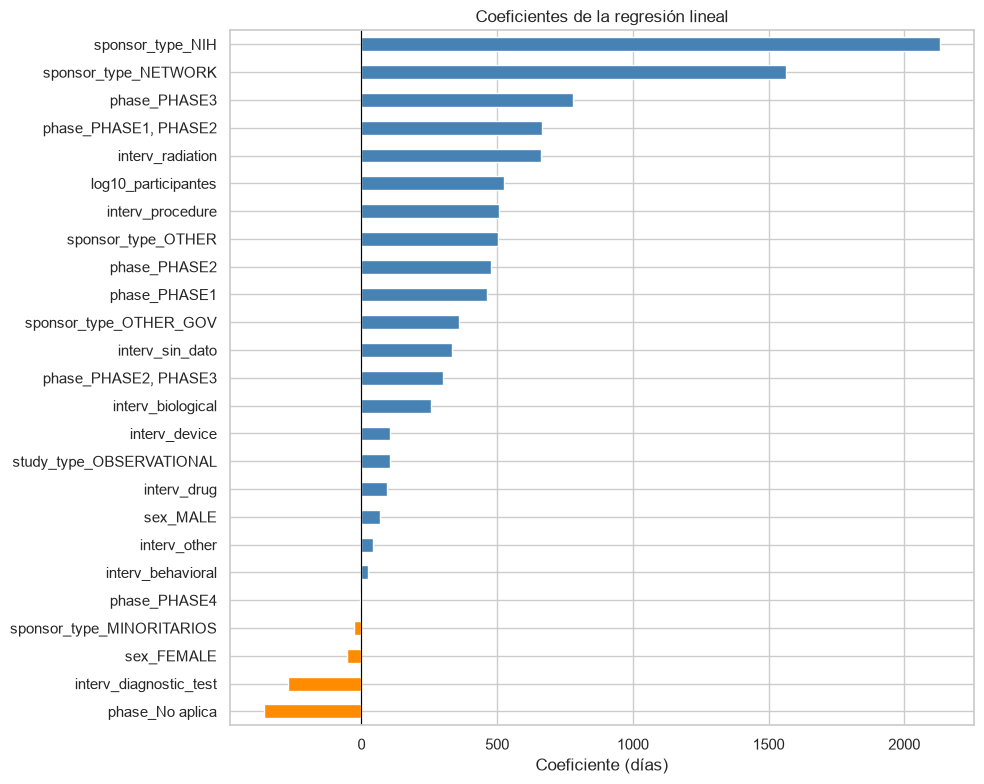

Intercepto (predicción base, con todas las variables en 0): -43 días
Categorías de referencia (eliminadas por drop='first'): ['INTERVENTIONAL', 'EARLY_PHASE1', 'INDUSTRY', 'ALL']


In [29]:
# === 5. Evaluación del modelo ===
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluar(modelo_, X_, y_):
    """Calcula MAE, RMSE y R² de un modelo sobre un conjunto de datos."""
    pred = modelo_.predict(X_)
    return {
        "MAE": mean_absolute_error(y_, pred),       # error absoluto medio (días)
        "RMSE": root_mean_squared_error(y_, pred),  # raíz del error cuadrático medio (días)
        "R2": r2_score(y_, pred),                   # proporción de la varianza explicada
    }

# --- 5.1 Métricas en entrenamiento y prueba, para ambos modelos ---
resultados = pd.DataFrame({
    ("Referencia (mediana)", "Entrenamiento"): evaluar(referencia, X_train, y_train),
    ("Referencia (mediana)", "Prueba"): evaluar(referencia, X_test, y_test),
    ("Regresión lineal", "Entrenamiento"): evaluar(modelo, X_train, y_train),
    ("Regresión lineal", "Prueba"): evaluar(modelo, X_test, y_test),
}).T.round(3)
display(resultados)

# Métricas de prueba del modelo base (se registrarán en MLflow en el Paso 6)
metricas_prueba = evaluar(modelo, X_test, y_test)
metricas_referencia = evaluar(referencia, X_test, y_test)
mejora_mae = 1 - metricas_prueba["MAE"] / metricas_referencia["MAE"]
print(f"Mejora del MAE frente a la referencia: {mejora_mae:.1%}")

# --- 5.2 Validación cruzada de 5 pliegues (solo con el conjunto de entrenamiento) ---
# Se entrena y evalúa 5 veces, cada vez dejando fuera una parte distinta del entrenamiento.
# Mide qué tan estable es el desempeño sin tocar el conjunto de prueba.
from sklearn.model_selection import KFold, cross_validate

N_PLIEGUES = 5
cv = cross_validate(
    modelo, X_train, y_train,
    cv=KFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEED),
    scoring={"MAE": "neg_mean_absolute_error",
             "RMSE": "neg_root_mean_squared_error",
             "R2": "r2"},
)
# scikit-learn devuelve los errores con signo negativo; se cambia el signo para MAE y RMSE
resultados_cv = pd.DataFrame({
    "MAE": -cv["test_MAE"],
    "RMSE": -cv["test_RMSE"],
    "R2": cv["test_R2"],
}, index=[f"Pliegue {i}" for i in range(1, N_PLIEGUES + 1)])
resultados_cv.loc["Media"] = resultados_cv.mean()
resultados_cv.loc["Desviación estándar"] = resultados_cv.iloc[:N_PLIEGUES].std()
print(f"Validación cruzada de {N_PLIEGUES} pliegues (regresión lineal, entrenamiento):")
display(resultados_cv.round(3))
metricas_cv = resultados_cv.loc["Media"].to_dict()  # se registrarán en MLflow en el Paso 6

# --- 5.3 Gráficas: real contra predicho y distribución de los residuos ---
pred_test = modelo.predict(X_test)
residuos = y_test - pred_test

fig, ejes = plt.subplots(1, 2, figsize=(14, 5.5))
ejes[0].scatter(y_test, pred_test, alpha=0.3, s=10)
limite = max(y_test.max(), pred_test.max())
ejes[0].plot([0, limite], [0, limite], color="red", linestyle="--", label="Predicción perfecta")
ejes[0].set_xlabel("Duración real (días)")
ejes[0].set_ylabel("Duración predicha (días)")
ejes[0].set_title("Real contra predicho (conjunto de prueba)")
ejes[0].legend()

sns.histplot(residuos, bins=50, ax=ejes[1])
ejes[1].axvline(0, color="red", linestyle="--")
ejes[1].set_xlabel("Residuo = real − predicho (días)")
ejes[1].set_ylabel("Frecuencia (número de ensayos)")
ejes[1].set_title("Distribución de los residuos (conjunto de prueba)")
plt.tight_layout()
plt.show()

# --- 5.4 Coeficientes: efecto estimado de cada variable sobre la duración ---
nombres = modelo.named_steps["preprocesamiento"].get_feature_names_out()
coeficientes = (pd.Series(modelo.named_steps["regresion"].coef_, index=nombres)
                .rename(lambda n: n.replace("onehot__", "").replace("remainder__", ""))
                .sort_values())
fig, ax = plt.subplots(figsize=(10, 8))
coeficientes.plot.barh(ax=ax, color=["darkorange" if c < 0 else "steelblue" for c in coeficientes])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (días)")
ax.set_title("Coeficientes de la regresión lineal")
plt.tight_layout()
plt.show()
print(f"Intercepto (predicción base, con todas las variables en 0): "
      f"{modelo.named_steps['regresion'].intercept_:,.0f} días")
print("Categorías de referencia (eliminadas por drop='first'):",
      [c[0] for c in modelo.named_steps["preprocesamiento"].named_transformers_["onehot"].categories_])

**Interpretación de la evaluación**

| Modelo | Evaluación | MAE (días) | RMSE (días) | R² |
|---|---|---|---|---|
| Referencia (mediana) | Prueba | 988.7 | 1,517.7 | −0.058 |
| Regresión lineal | Entrenamiento | 891.6 | 1,269.9 | 0.226 |
| Regresión lineal | Validación cruzada (media ± desv. estándar) | 894.3 ± 39.3 | 1,272.6 ± 76.9 | 0.220 ± 0.009 |
| Regresión lineal | Prueba | **884.7** | **1,294.8** | **0.230** |

- **¿Aprende algo el modelo?** Sí. Supera al modelo de referencia en las tres métricas: reduce el MAE un **10.5%** (de 988.7 a 884.7 días) y explica el **23%** de la variabilidad de la duración, mientras que la referencia no explica nada (R² negativo, porque predice la mediana y no la media).
- **¿Es estable?** Sí. En la validación cruzada el R² varía muy poco entre pliegues (0.220 ± 0.009), y el resultado en prueba (0.230) está dentro de ese rango. El desempeño no depende de una división afortunada de los datos.
- **¿Qué tan bueno es?** Modesto. Un MAE de 884.7 días (≈ 2.4 años) es grande frente a una duración mediana de 1,292 días, y el 77% de la variabilidad queda sin explicar. Es un **punto de partida**, no un modelo listo para usarse.
- **Sobreajuste:** no hay. Las métricas de entrenamiento, validación cruzada y prueba son casi iguales. El problema es el contrario: el modelo es **demasiado simple** (subajuste) para capturar la complejidad del fenómeno.
- **Errores grandes:** el RMSE (1,294.8) es bastante mayor que el MAE (884.7), señal de errores grandes en algunos ensayos. La gráfica de real contra predicho lo confirma: el modelo casi no predice duraciones mayores a ~4,000 días, por lo que **subestima los ensayos largos**, y los residuos tienen una cola larga hacia la derecha.
- **Coeficientes** (comparados con las categorías de referencia: INTERVENTIONAL, EARLY_PHASE1, INDUSTRY y ALL): ser patrocinado por NIH (+2,133 días) o NETWORK (+1,563) y estar en Fase 3 (+781) se asocian con mayor duración; la fase "No aplica" (−360) con menor duración. Multiplicar por 10 el número de participantes se asocia con +526 días. Estos coeficientes indican **asociación, no causalidad**.
- **Intercepto o predicción base (−43 días):** es la predicción cuando todas las variables valen 0 (categorías de referencia, 1 participante y sin tipo de intervención). Ese caso no existe en los datos, por lo que no tiene interpretación práctica por sí solo; funciona como punto de partida al que cada coeficiente suma o resta días.
- **Posibles mejoras** (fuera del alcance del modelo base): transformar la variable objetivo con logaritmo para reducir el efecto de los ensayos largos, probar modelos no lineales (árboles de decisión, *gradient boosting*), ajustar hiperparámetros con validación cruzada e incorporar información de las condiciones estudiadas.

## 6. Registro del experimento en MLflow

El modelo base se registra en una segunda ejecución (`02_modelo_base`) del mismo experimento, ligada a la ejecución de preparación de datos (`01_preparacion_datos`) mediante una etiqueta con su identificador y el mismo conjunto de datos de entrada (misma huella digital). Se registran:

- **Parámetros:** tipo de modelo, variables, codificación, tamaño de prueba, semilla y número de pliegues.
- **Métricas:** MAE, RMSE y R² en prueba; media y desviación estándar de la validación cruzada; métricas del modelo de referencia y mejora del MAE.
- **Modelo:** el `Pipeline` completo (codificación + regresión), con su firma (columnas y tipos de entrada y salida) y un ejemplo de entrada, para poder cargarlo y usarlo después.
- **Artefactos:** tablas de métricas, validación cruzada y coeficientes, la gráfica de real contra predicho y el archivo de dependencias (`requirements-lock.txt`).

In [30]:
# === 6. Registro del modelo base en MLflow ===
from mlflow.models import infer_signature

with mlflow.start_run(run_name="02_modelo_base") as run_modelo:
    # 1) Etiquetas: describen la ejecución y la ligan con la de preparación de datos
    mlflow.set_tags({
        "etapa": "modelo_base",
        "autor": "Roberto Robles",
        "tipo_modelo": "LinearRegression",
        "run_preparacion_datos": RUN_ID_DATOS,  # linaje: de qué limpieza vienen los datos
    })

    # 2) Datos de entrada: el mismo conjunto limpio (misma huella digital que en 01)
    mlflow.log_input(ds_limpio, context="entrenamiento")

    # 3) Parámetros: todo lo necesario para reproducir el entrenamiento
    mlflow.log_params({
        "modelo": "LinearRegression",
        "variable_objetivo": OBJETIVO,
        "variables_categoricas": ", ".join(CATEGORICAS),
        "codificacion": "OneHotEncoder(drop='first', handle_unknown='ignore')",
        "variables_modelo": len(modelo.named_steps["preprocesamiento"].get_feature_names_out()),
        "test_size": TEST_SIZE,
        "semilla": SEED,
        "pliegues_validacion_cruzada": N_PLIEGUES,
        "registros_entrenamiento": len(X_train),
        "registros_prueba": len(X_test),
    })

    # 4) Métricas: prueba, validación cruzada y modelo de referencia
    mlflow.log_metrics({
        "prueba_mae": metricas_prueba["MAE"],
        "prueba_rmse": metricas_prueba["RMSE"],
        "prueba_r2": metricas_prueba["R2"],
        "cv_mae_media": resultados_cv.loc["Media", "MAE"],
        "cv_mae_desv": resultados_cv.loc["Desviación estándar", "MAE"],
        "cv_rmse_media": resultados_cv.loc["Media", "RMSE"],
        "cv_r2_media": resultados_cv.loc["Media", "R2"],
        "cv_r2_desv": resultados_cv.loc["Desviación estándar", "R2"],
        "referencia_mae": metricas_referencia["MAE"],
        "referencia_r2": metricas_referencia["R2"],
        "mejora_mae_vs_referencia": mejora_mae,
    })

    # 5) Modelo: el Pipeline completo (codificación + regresión), con su firma
    #    (columnas y tipos de entrada/salida) y un ejemplo de entrada
    firma = infer_signature(X_train, modelo.predict(X_train))
    mlflow.sklearn.log_model(modelo, name="modelo_base",
                             signature=firma, input_example=X_train.head(5))

    # 6) Artefactos de evaluación: tablas, coeficientes y gráfica
    mlflow.log_table(resultados.reset_index(names=["modelo", "conjunto"]),
                     artifact_file="evaluacion/metricas.json")
    mlflow.log_table(resultados_cv.reset_index(names=["pliegue"]),
                     artifact_file="evaluacion/validacion_cruzada.json")
    mlflow.log_table(coeficientes.rename_axis("variable").reset_index(name="coeficiente_dias"),
                     artifact_file="evaluacion/coeficientes.json")

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.scatter(y_test, pred_test, alpha=0.3, s=10)
    ax.plot([0, limite], [0, limite], color="red", linestyle="--", label="Predicción perfecta")
    ax.set_xlabel("Duración real (días)")
    ax.set_ylabel("Duración predicha (días)")
    ax.set_title("Real contra predicho (conjunto de prueba)")
    ax.legend()
    mlflow.log_figure(fig, "evaluacion/real_contra_predicho.png")
    plt.close(fig)

    mlflow.log_artifact("requirements-lock.txt", artifact_path="entorno")
    RUN_ID_MODELO = run_modelo.info.run_id

print(f"Experimento : {EXPERIMENTO}")
print(f"Ejecución   : 02_modelo_base (run_id = {RUN_ID_MODELO})")
print(f"Ligada a    : 01_preparacion_datos (run_id = {RUN_ID_DATOS})")
print(f"Métricas de prueba registradas: MAE = {metricas_prueba['MAE']:,.1f} | "
      f"RMSE = {metricas_prueba['RMSE']:,.1f} | R² = {metricas_prueba['R2']:.3f}")

/Users/Roberto/Library/CloudStorage/Dropbox/ITESM - Maestría IA/Cursos/Trim3 - Operaciones de Aprendizaje Automático/Semana 3/Actividad/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Experimento : TC5061_Semana3_Baseline_DuracionEnsayos
Ejecución   : 02_modelo_base (run_id = 706ec96515cb48119181927f56dd86c2)
Ligada a    : 01_preparacion_datos (run_id = 9b4cbae075404df482854ac816524113)
Métricas de prueba registradas: MAE = 884.7 | RMSE = 1,294.8 | R² = 0.230


**Evidencia en MLflow: experimento `TC5061_Semana3_Baseline_DuracionEnsayos`**

*Figura 5. Ejecuciones del experimento: `01_preparacion_datos` y `02_modelo_base`. Ambas usan el conjunto limpio con la misma huella digital (`5c86b1e2`), lo que evidencia el linaje de los datos.*

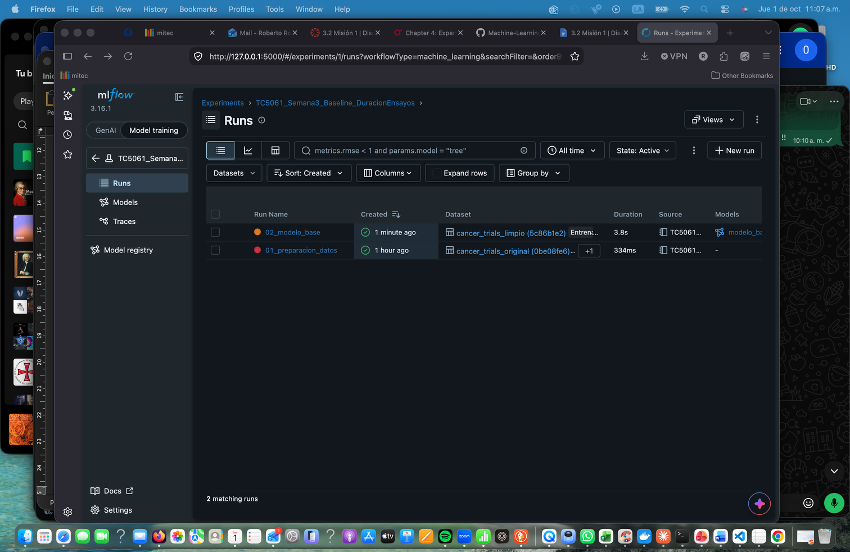

*Figuras 6.1 y 6.2 Ejecución `02_modelo_base`: parámetros, métricas, etiquetas (incluido el vínculo con la preparación de datos) y modelo registrado.*

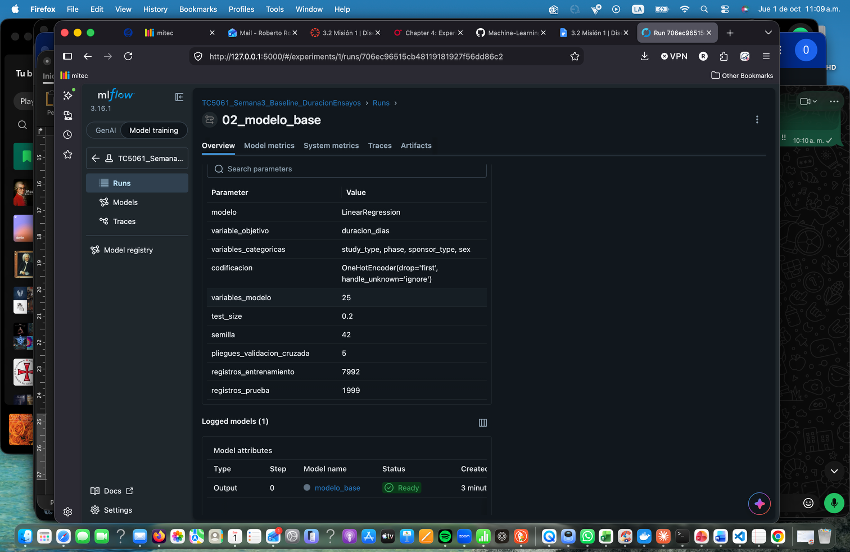

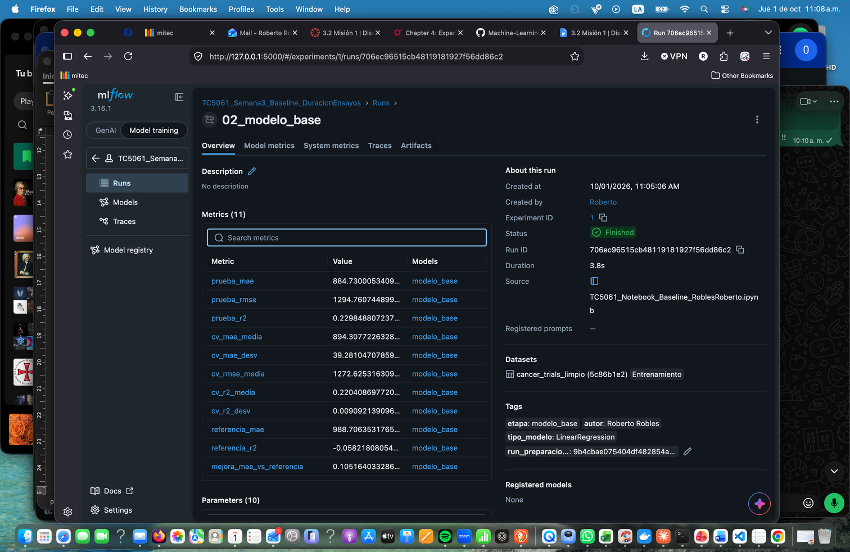

*Figura 7. Gráfica de real contra predicho registrada como artefacto.*

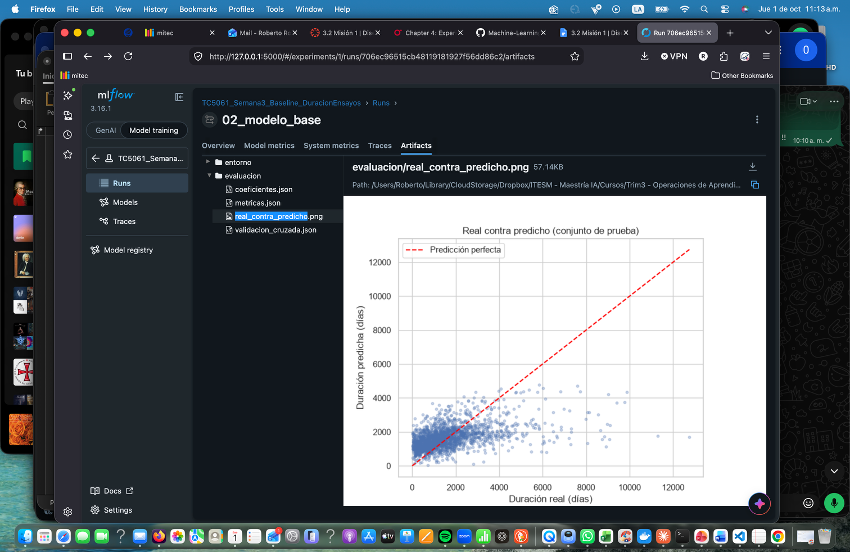

**Resultado del registro:** el experimento contiene dos ejecuciones ligadas que, juntas, documentan el punto de partida completo: qué datos se usaron (huella digital), cómo se limpiaron (decisiones y bitácora), cómo se entrenó el modelo (parámetros y semilla), qué desempeño tuvo (métricas de prueba, validación cruzada y referencia), el modelo listo para cargarse y el entorno con el que se generó (`requirements-lock.txt`).

## 7. Reflexión final

### Prácticas de MLOps aplicadas en la presente actividad

Antes de iniciar la codificación, se definió un flujo para que el punto de partida fuera **reproducible y trazable**. Además de lo requerido en la actividad, se agregaron prácticas de trazabilidad que se describen a continuación:

    Actividad/
    ├── .venv/                                        ← entorno aislado
    ├── cancer_trials_2020_2024.csv                   ← conjunto de datos original intacto
    ├── requirements.txt                              ← qué necesita el proyecto
    ├── requirements-lock.txt                         ← versiones exactas congeladas
    ├── TC5061_Notebook_Baseline_RoblesRoberto.ipynb  ← flujo completo y evidencia
    ├── mlflow.db                                     ← registro de experimentos
    └── mlruns/                                       ← artefactos: datos limpios, bitácora, modelo y gráficas

- **Entorno aislado** y dependencias declaradas en archivos (no instaladas desde el notebook); el propio notebook imprime las versiones y congela el entorno.
- **Semilla fija** en la división de datos y en la validación cruzada.
- **Datos originales intactos:** todas las transformaciones se hicieron sobre una copia, y cada decisión de limpieza quedó en una **bitácora** con los registros afectados.
- **Linaje de datos en MLflow:** dos ejecuciones ligadas (preparación de datos y modelo base) que registran los conjuntos de datos con su huella digital, las decisiones, los parámetros, las métricas, el modelo y el entorno. La huella digital del conjunto limpio (`5c86b1e2`) es la misma en ambas ejecuciones (Figuras 3 y 6.2), lo que permite verificar con qué datos exactos se entrenó el modelo.

### Qué mejoraría y por qué

1. **Pasar del notebook a un flujo modular.** Dividir el trabajo en archivos .py, uno por etapa, que se ejecutan siempre de principio a fin. Un flujo modular se ejecuta siempre igual y se puede automatizar.
2. **Publicar el proyecto en un repositorio de GitHub para trabajo colaborativo.** Esta actividad fue individual y todo vive en mi computadora, pero en un proyecto real varias personas necesitarían trabajar sobre el mismo flujo. Un repositorio permitiría revisar los cambios antes de integrarlos y conservar el historial de quién cambió qué y por qué.
3. **Validaciones automáticas de calidad de datos** (esquema, rangos, duraciones no negativas). Mis decisiones de limpieza se basaron en una revisión manual; con datos nuevos podrían aparecer problemas que nadie revise.
4. **Comparar modelos de forma sistemática y usar el registro de modelos de MLflow** para promover solo al mejor. El modelo base explica apenas el 23% de la variabilidad, por lo que el siguiente paso natural es probar modelos no lineales con ajuste de hiperparámetros.
5. **Monitorear el modelo** si se pusiera en producción, porque solo se entrenó con ensayos terminados entre 2020 y 2024 y los ensayos futuros podrían comportarse distinto.

El análisis exploratorio es una práctica de MLOps en sí misma: ahí se detectó la **fuga de información** del año de inicio, un error que habría producido un modelo aparentemente excelente pero inútil. Y nuevamente comprobé que algunas conclusiones requieren **conocimiento del dominio** (por ejemplo, el significado de las fases clínicas), que debe venir de expertos o de fuentes citadas, no de suposiciones.

### Aplicación en mi área profesional

Fundé y dirijo, desde hace más de 20 años, una empresa de consultoría e implantación de proyectos de transformación digital, que hoy debe complementar su práctica con inteligencia artificial. Este conjunto de prácticas de MLOps me ha aportado un aprendizaje enorme, porque me permite:

- **Definir mejor el alcance** de un proyecto de IA: no solo el modelo, sino también el entorno reproducible, la calidad y el versionado de los datos, el registro de experimentos y el monitoreo en operación.
- **Dimensionar el equipo requerido**, incluyendo expertos del dominio; en esta actividad comprobé que hay conclusiones que los datos por sí solos no pueden explicar.
- **Supervisar y dar seguimiento** con métricas objetivas, comparando siempre contra un modelo de referencia.
- **Garantizar la trazabilidad** de la construcción, entrega y operación de la solución, como lo hicieron aquí la bitácora de limpieza y las ejecuciones ligadas en MLflow.

Por ello, considero que la aplicación de MLOps es primordial en cualquier proyecto de IA.

## Referencias

Abdurrahmanhakanacar. (s. f.). *Global oncology clinical trials 2020–2024* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/abdurrahmanhakanacar/global-oncology-clinical-trials-2020-2024


Anthropic. (2026). *Claude Code* (Modelo Claude Opus 5.5) [Asistente de programación basado en un modelo de lenguaje de gran tamaño], utilizado para generación de código, depuración y apoyo en la redacción de las interpretaciones y la reflexión, revisados y ajustados por el autor. https://claude.com/claude-code
